# Assignment #6: Frequent Pattern-Augmented Classification Model

1. Aditya Murti Kusuma Atmaja 25/563098/PPA/07099
2. Fawwaz Rif'at Revista 25/565782/PPA/07130
3. Khalilullah Al Faath 25/566643/PPA/07139
4. Reza Ananda Hatmi 25/565054/PPA/07124

Paper's title: **A Novel Approach Utilizing Machine Learning for the Early Diagnosis of Alzheimer's Disease**

Paper's link: https://link-springer-com.ezproxy.ugm.ac.id/article/10.1007/s44174-023-00078-9

Dataset's link: https://www.kaggle.com/datasets/shashwatwork/dementia-prediction-dataset/data

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Data Exploration

## Import libraries and dataset via Kaggle

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/dementia-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dementia-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/dementia-prediction-dataset


## Load Data

In [ ]:
from pathlib import Path
df = pd.read_csv(Path(path+"/dementia_dataset.csv"))

In [ ]:
df.head(5)

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


## initial Data Examination

In [ ]:
# Show the first five data
df.head(5)

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [ ]:
# Show the last 5 data
df.tail(5)

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
368,OAS2_0185,OAS2_0185_MR2,Demented,2,842,M,R,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,OAS2_0186,OAS2_0186_MR1,Nondemented,1,0,F,R,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,OAS2_0186,OAS2_0186_MR2,Nondemented,2,763,F,R,63,13,2.0,30.0,0.0,1327,0.796,1.323
372,OAS2_0186,OAS2_0186_MR3,Nondemented,3,1608,F,R,65,13,2.0,30.0,0.0,1333,0.801,1.317


In [ ]:
# Show a data sample
df.sample()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
259,OAS2_0126,OAS2_0126_MR2,Nondemented,2,472,F,R,75,12,3.0,29.0,0.0,1338,0.747,1.312


In [ ]:
# Show dataset dimension
df.shape

(373, 15)

This dataset has 373 rows and 15 columns

In [ ]:
# Show the general info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Subject ID  373 non-null    object 
 1   MRI ID      373 non-null    object 
 2   Group       373 non-null    object 
 3   Visit       373 non-null    int64  
 4   MR Delay    373 non-null    int64  
 5   M/F         373 non-null    object 
 6   Hand        373 non-null    object 
 7   Age         373 non-null    int64  
 8   EDUC        373 non-null    int64  
 9   SES         354 non-null    float64
 10  MMSE        371 non-null    float64
 11  CDR         373 non-null    float64
 12  eTIV        373 non-null    int64  
 13  nWBV        373 non-null    float64
 14  ASF         373 non-null    float64
dtypes: float64(5), int64(5), object(5)
memory usage: 43.8+ KB


This dataset has 15 columns, with 5 columns are string, 5 are integer, and the others are float.

## Check for Duplicate Rows

In [ ]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

This dataset has 0 data duplicate

## Summary Statistics

In [ ]:
# Show the descriptive analysis of the dataset
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


The participants' ages range from 60 to 98 years, with an average age of approximately 77. This cohort is generally well-educated, averaging about 14.6 years of formal education (equivalent to some college or a degree), and represents a moderate socioeconomic status (SES). However, the dataset is not entirely complete; there are 19 missing values in the SES column and 2 missing values in the MMSE column.

From a clinical and cognitive standpoint, the majority of the participants appear to be healthy, but there is a clear spectrum of cognitive decline. The Mini-Mental State Examination (MMSE) scores have an average of 27.34 and a median of 29, which falls within the normal cognitive range. Similarly, the median Clinical Dementia Rating (CDR) is 0, suggesting no dementia for most individuals. Despite this, the data captures severe cases of cognitive impairment as well, with MMSE scores dropping as low as 4 and CDR scores reaching 2, which indicates moderate dementia.

The neurological MRI scans align with these varied cognitive profiles. The Estimated Total Intracranial Volume (eTIV) averages around 1488 cm³, while the Normalized Whole Brain Volume (nWBV) averages 0.729, with a minimum of 0.644—indicating significant brain atrophy in some patients. The longitudinal design of the study is evident from the "MR Delay" variable, which measures the days between visits. This variable shows extreme variance, ranging from 0 to 2639 days, highlighting highly inconsistent follow-up intervals among patients.

## Identify missing values

In [ ]:
df.isnull().sum()

,0
Subject ID,0
MRI ID,0
Group,0
Visit,0
MR Delay,0
M/F,0
Hand,0
Age,0
EDUC,0
SES,19


There are 19 missing values on SES column and 2 missing values on MMSE column.

## Check for outliers

CATATAN CEK DULU METODENYA APAKAH MAU PAKAI ZSCORE ATAU IQR

In [ ]:
# Uji Normalitas dengan Uji Skewness
num_features = ['MR Delay', 'Age', 'EDUC', 'MMSE', 'eTIV', 'nWBV', 'ASF']

print("Hasil Uji Skewness:")
print("-" * 30)

for col in num_features:
    skew_val = df[col].skew()
    print(f"{col:<10} : {skew_val:.4f}")

Hasil Uji Skewness:
------------------------------
MR Delay   : 0.9450
Age        : 0.1417
EDUC       : -0.0260
MMSE       : -2.3661
eTIV       : 0.4969
nWBV       : 0.2346
ASF        : 0.0835


Berdasarkan hasil uji skewness, terdapat fitur yang berdistribusi normal, moderate skewed, dan highly skewed. Fitur yang berdistribusi normal adalah Age, EDUC, eTIV, nWBV, dan ASF. Fitur yang memiliki kemiringan moderat adalah MR Delay. Sedangkan fitur yang highly skewed adalah MMSE. Secara visual, uji distribusi normalitas data dapat dilihat dari Kurva Lonceng, jika kurvanya berbentuk lonceng maka kemungkinan besar fitur tersebut terdistribusi normal.

In [ ]:
num_features = [
    'MR Delay', 'Age', 'EDUC',
    'MMSE', 'eTIV', 'nWBV', 'ASF',
]

outliers_result = []

# calculate mean, std, and outliers num for each num_features
for i in num_features:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)]

    kolom_result = {
        "column": i,
        "mean": df[i].mean(),
        "std": df[i].std(),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outliers_count": outliers.shape[0]
    }

    outliers_result.append(kolom_result)

df_outliers = pd.DataFrame(outliers_result)


In [ ]:
df_outliers

,column,mean,std,lower_bound,upper_bound,outliers_count
0,MR Delay,595.104558,635.485118,-1309.500,2182.500,8
1,Age,77.013405,7.640957,54.500,98.500,0
2,EDUC,14.597855,2.876339,6.000,22.000,3
3,MMSE,27.342318,3.683244,22.500,34.500,42
4,eTIV,1488.128686,176.139286,997.000,1957.000,2
5,nWBV,0.729568,0.037135,0.616,0.840,0
6,ASF,1.195461,0.138092,0.808,1.584,1


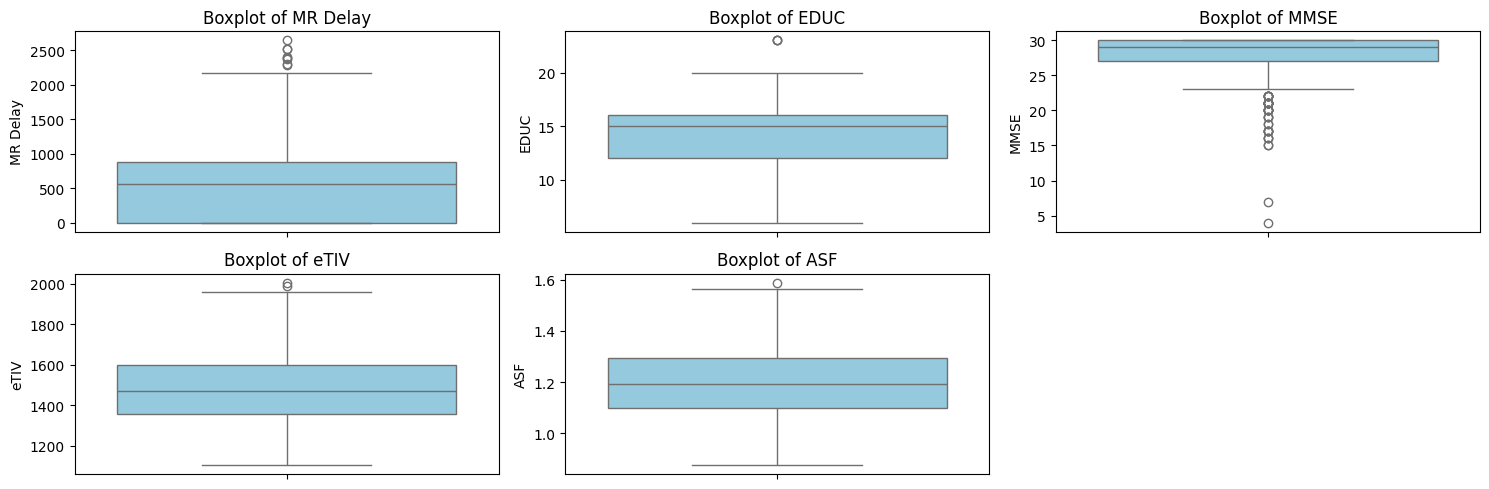

In [ ]:
cols_with_outliers = ['MR Delay', 'EDUC', 'MMSE', 'eTIV', 'ASF']

plt.figure(figsize=(15, 5))

for i, col in enumerate(cols_with_outliers, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

In [ ]:
for col in cols_with_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_rows = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{'='*40}")
    print(f"Outlier Rows for: {col} (Total: {outlier_rows.shape[0]})")
    print(f"{'='*40}")

    display(outlier_rows)


Outlier Rows for: MR Delay (Total: 8)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
32,OAS2_0017,OAS2_0017_MR5,Nondemented,5,2400,M,R,86,12,3.0,27.0,0.0,1813,0.761,0.968
71,OAS2_0036,OAS2_0036_MR5,Nondemented,5,2369,F,R,75,13,4.0,29.0,0.0,1349,0.778,1.301
75,OAS2_0037,OAS2_0037_MR4,Demented,4,2508,M,R,89,12,4.0,26.0,0.5,1485,0.706,1.181
153,OAS2_0070,OAS2_0070_MR5,Nondemented,5,2386,M,R,86,17,1.0,30.0,0.0,1720,0.705,1.020
159,OAS2_0073,OAS2_0073_MR4,Nondemented,4,2288,F,R,76,14,3.0,29.0,0.0,1490,0.774,1.178
160,OAS2_0073,OAS2_0073_MR5,Nondemented,5,2517,F,R,77,14,3.0,29.0,0.0,1504,0.769,1.167
265,OAS2_0127,OAS2_0127_MR5,Converted,5,2639,M,R,86,18,1.0,30.0,0.5,1670,0.669,1.051
369,OAS2_0185,OAS2_0185_MR3,Demented,3,2297,M,R,86,16,1.0,26.0,0.5,1688,0.675,1.040



Outlier Rows for: EDUC (Total: 3)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
107,OAS2_0051,OAS2_0051_MR1,Nondemented,1,0,F,R,92,23,1.0,29.0,0.0,1454,0.701,1.207
108,OAS2_0051,OAS2_0051_MR2,Nondemented,2,457,F,R,94,23,1.0,29.0,0.0,1474,0.696,1.190
109,OAS2_0051,OAS2_0051_MR3,Nondemented,3,1526,F,R,97,23,1.0,30.0,0.0,1483,0.689,1.184



Outlier Rows for: MMSE (Total: 42)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034
25,OAS2_0014,OAS2_0014_MR1,Demented,1,0,M,R,76,16,3.0,21.0,0.5,1602,0.697,1.096
26,OAS2_0014,OAS2_0014_MR2,Demented,2,504,M,R,77,16,3.0,16.0,1.0,1590,0.696,1.104
43,OAS2_0023,OAS2_0023_MR1,Demented,1,0,F,R,86,12,4.0,21.0,0.5,1247,0.662,1.407
44,OAS2_0023,OAS2_0023_MR2,Demented,2,578,F,R,87,12,4.0,21.0,0.5,1250,0.652,1.405
51,OAS2_0028,OAS2_0028_MR1,Demented,1,0,M,R,64,18,2.0,22.0,0.5,1547,0.737,1.134
52,OAS2_0028,OAS2_0028_MR2,Demented,2,610,M,R,66,18,2.0,21.0,1.0,1562,0.717,1.124
60,OAS2_0032,OAS2_0032_MR1,Demented,1,0,M,R,90,12,3.0,21.0,0.5,1307,0.679,1.342
88,OAS2_0044,OAS2_0044_MR1,Demented,1,0,M,R,68,14,4.0,21.0,1.0,1333,0.685,1.317
89,OAS2_0044,OAS2_0044_MR2,Demented,2,352,M,R,69,14,4.0,15.0,1.0,1331,0.678,1.318



Outlier Rows for: eTIV (Total: 2)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876



Outlier Rows for: ASF (Total: 1)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
282,OAS2_0138,OAS2_0138_MR2,Nondemented,2,846,F,R,75,16,2.0,28.0,0.0,1106,0.767,1.587


TODO PENJELASAN

## Explore Data Distributions

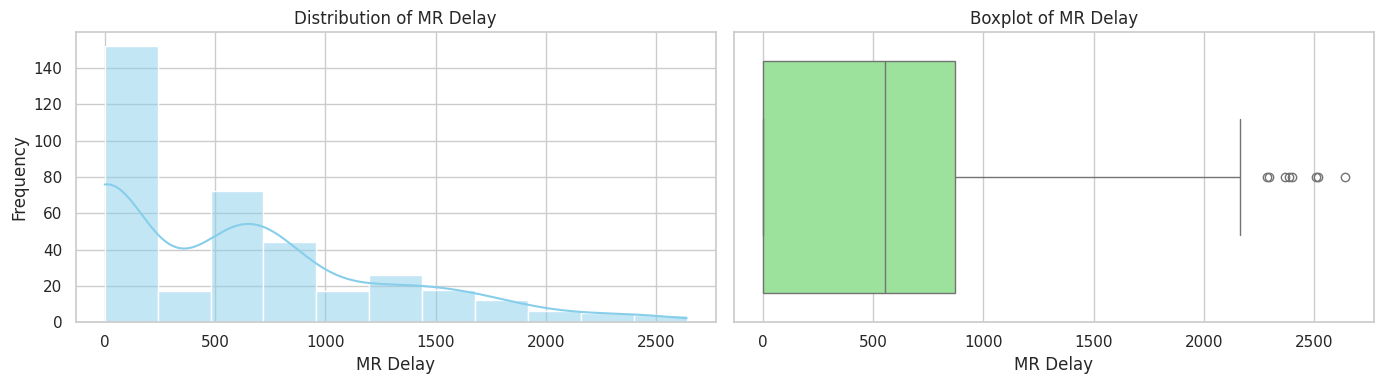

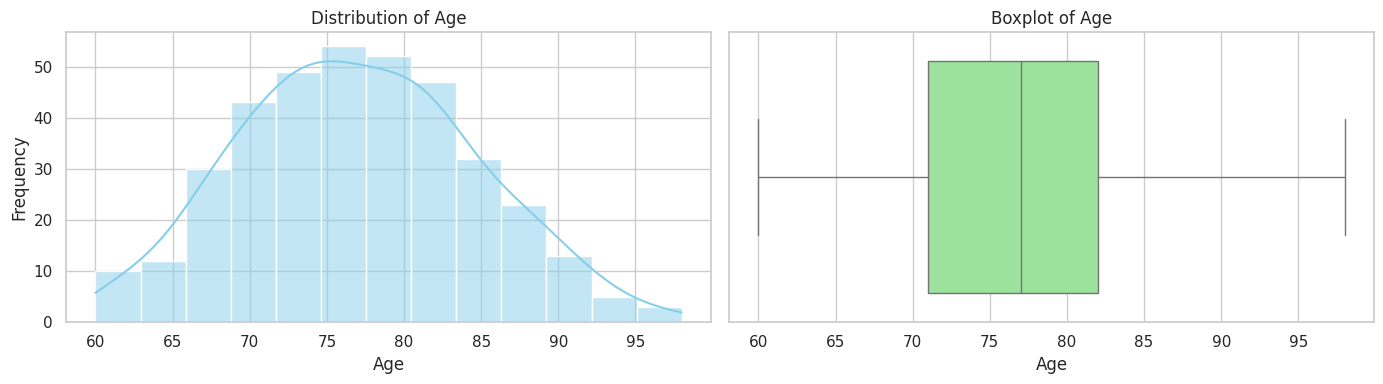

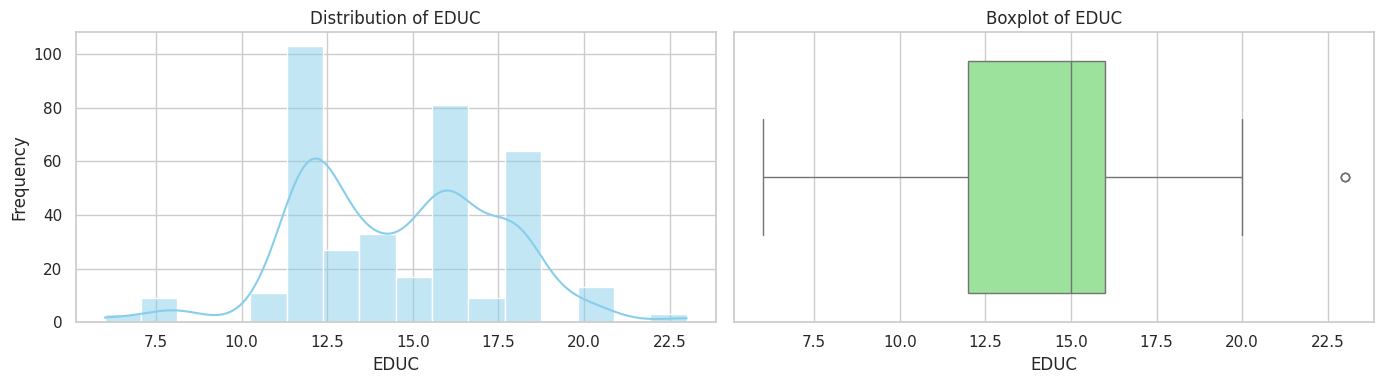

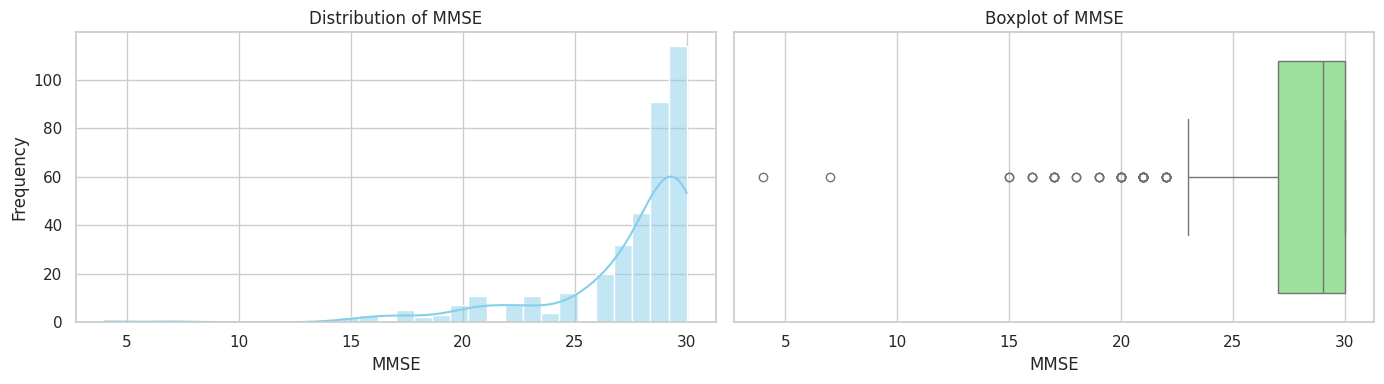

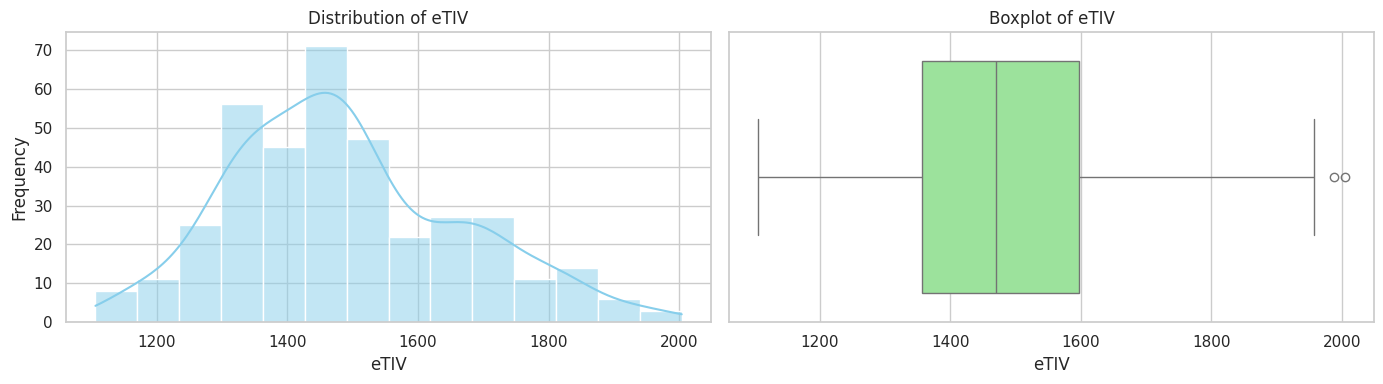

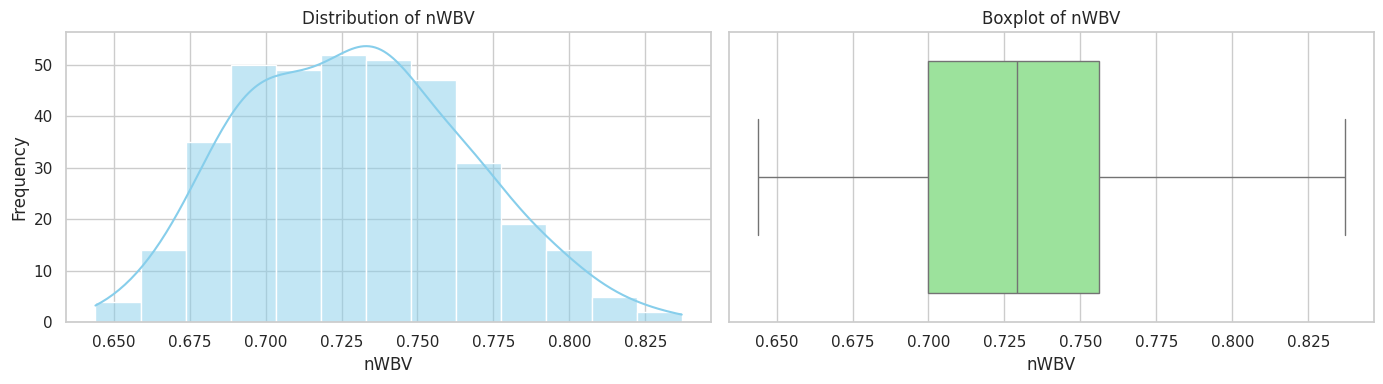

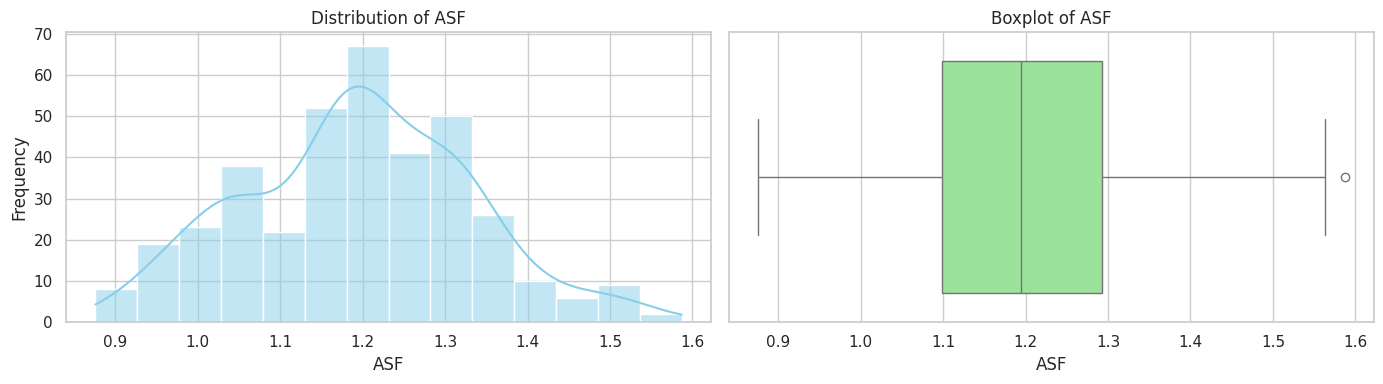

In [ ]:
sns.set_theme(style="whitegrid")

for col in num_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_ylabel('Frequency')

    sns.boxplot(data=df, x=col, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

TODO: PENJELASAN

## Categorical Data Exploration

/tmp/ipykernel_15995/3299802251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


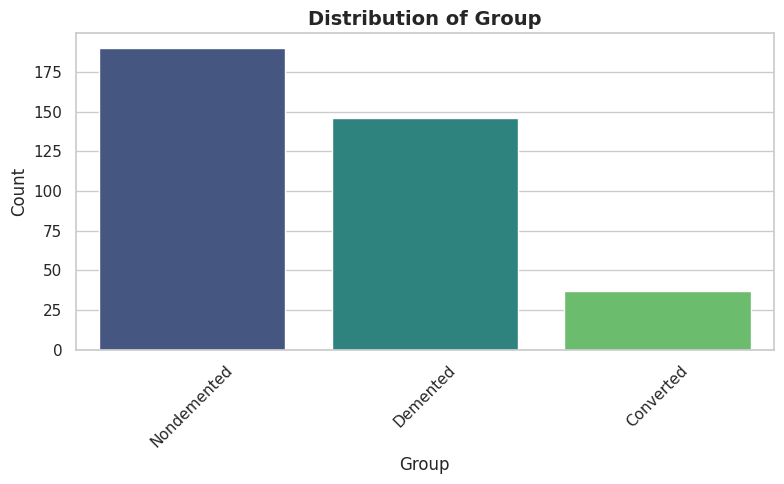

/tmp/ipykernel_15995/3299802251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


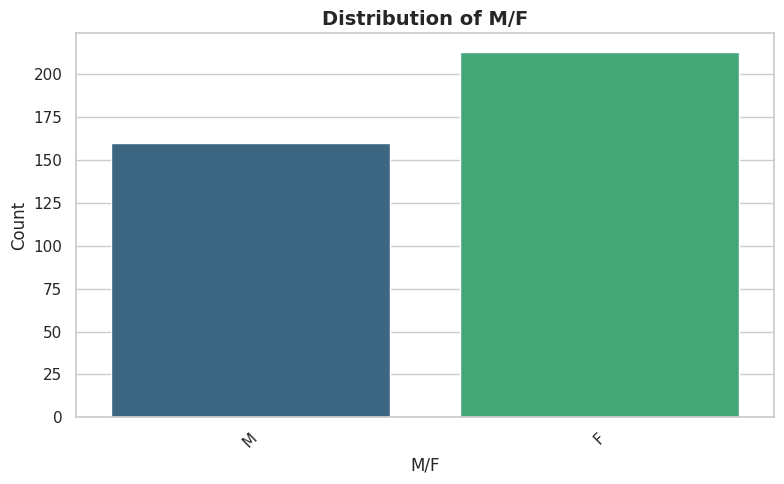

/tmp/ipykernel_15995/3299802251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


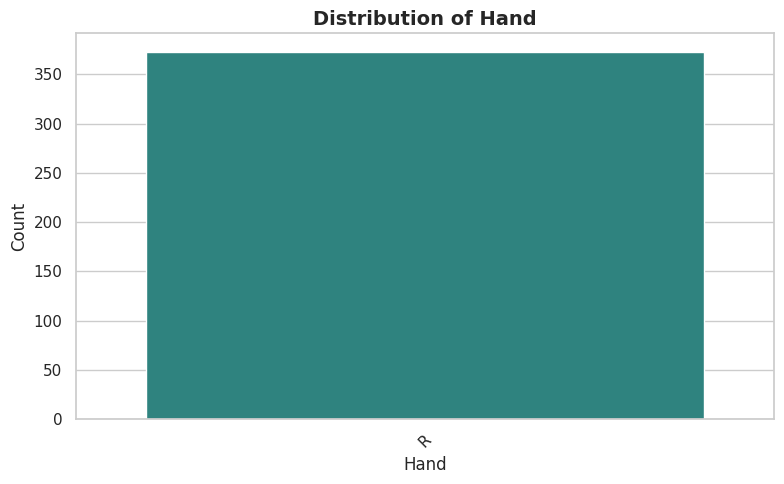

/tmp/ipykernel_15995/3299802251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


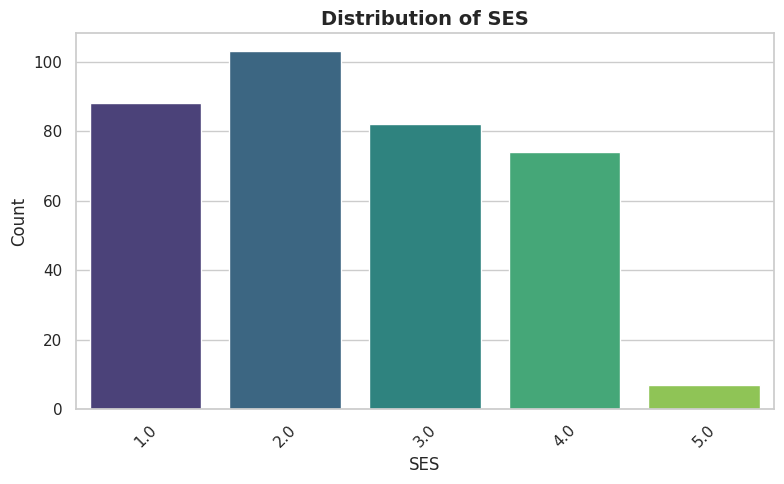

/tmp/ipykernel_15995/3299802251.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


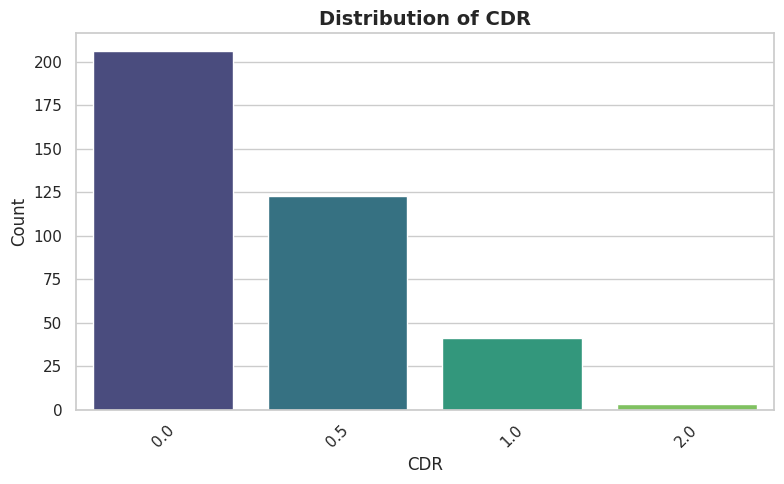

In [ ]:
cat_features = [
    'Group', 'M/F', 'Hand', 'SES', 'CDR'
]

sns.set_theme(style="whitegrid")

for col in cat_features:
    plt.figure(figsize=(8, 5))

    sns.countplot(data=df, x=col, palette='viridis')

    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.ylabel('Count', fontsize=12)
    plt.xlabel(col, fontsize=12)

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

TODO: PENJELASAN

## Correlation Analysis

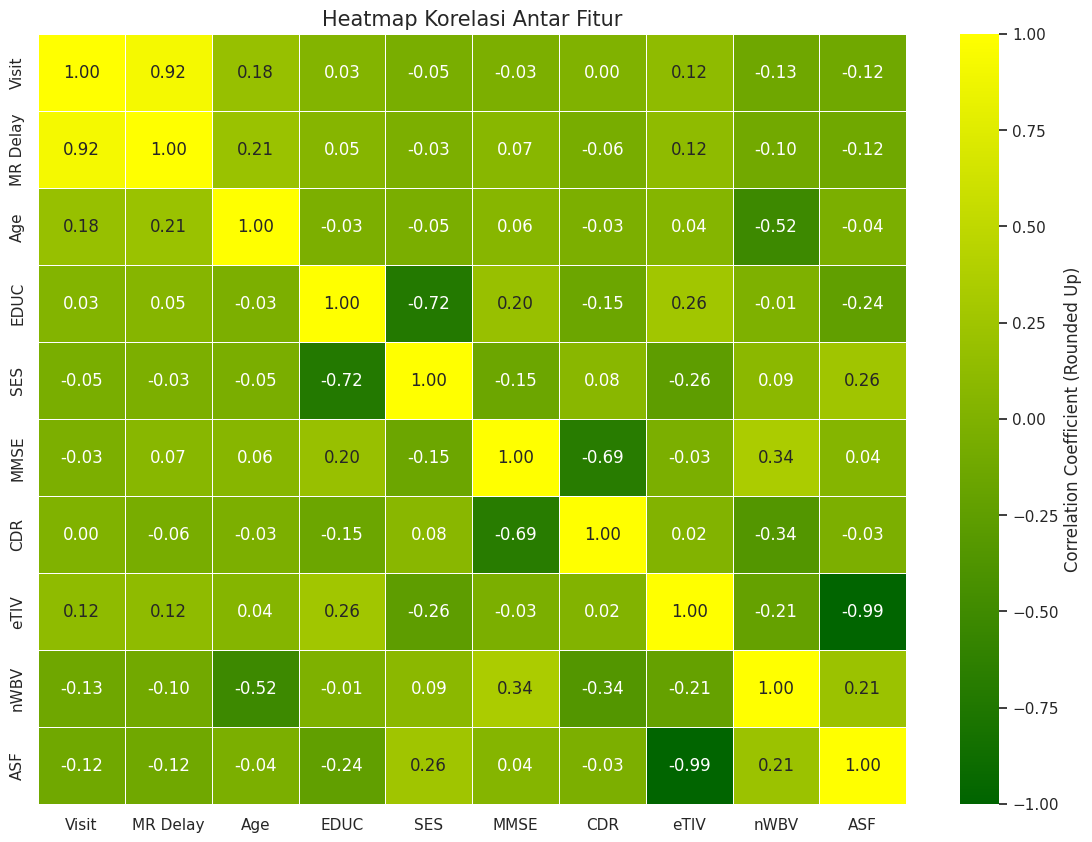

In [ ]:
selected_features = ['Visit', 'MR Delay', 'Age', 'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']

corr_matrix = df[selected_features].corr()

corr_matrix_rounded = np.ceil(corr_matrix * 1000) / 1000

custom_cmap = LinearSegmentedColormap.from_list("green_yellow", ["#006400", "#FFFF00"])

plt.figure(figsize=(14, 10))

tick_locations = np.arange(-1, 1.25, 0.25)

sns.heatmap(corr_matrix_rounded,
            annot=True,
            fmt=".2f",
            cmap=custom_cmap,
            linewidths=0.7,
            vmin=-1.0,
            vmax=1.0,
            cbar_kws={
                'label': 'Correlation Coefficient (Rounded Up)',
                'ticks': tick_locations
            })

plt.title("Heatmap Korelasi Antar Fitur", fontsize=15)
plt.show()

TODO: PENJELASAN

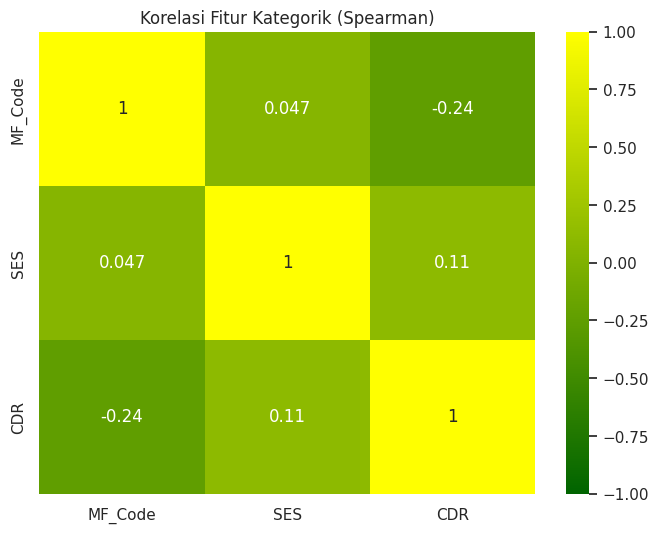

In [ ]:
df_copy = df.copy()

df_copy['MF_Code'] = df_copy['M/F'].map({'M': 0, 'F': 1})

kat_features = ['MF_Code', 'SES', 'CDR']
corr_kat = df_copy[kat_features].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_kat, annot=True, cmap=custom_cmap, vmin=-1, vmax=1)
plt.title("Korelasi Fitur Kategorik (Spearman)")
plt.show()

In [ ]:
# Uji Korelasi Spearman (Ordina-Ordinal)
spearman_result = df_copy[['SES', 'CDR']].corr(method='spearman')

nilai_korelasi = spearman_result.loc['SES', 'CDR']
print(f"Korelasi SES-CDR: {nilai_korelasi:.4f}")

Korelasi SES-CDR: 0.1071


In [ ]:
from scipy.stats import mannwhitneyu

df_clean = df_copy.dropna(subset=['M/F', 'SES', 'CDR'])

# M/F vs SES
ses_m = df_clean[df_clean['M/F'] == 'M']['SES']
ses_f = df_clean[df_clean['M/F'] == 'F']['SES']
stat_ses, p_ses = mannwhitneyu(ses_m, ses_f)

# M/F vs CDR
cdr_m = df_clean[df_clean['M/F'] == 'M']['CDR']
cdr_f = df_clean[df_clean['M/F'] == 'F']['CDR']
stat_cdr, p_cdr = mannwhitneyu(cdr_m, cdr_f)

# Tampilkan hasil P-Value
print(f"P-Value M/F vs SES : {p_ses:.4f}")
print(f"P-Value M/F vs CDR : {p_cdr:.4f}")

P-Value M/F vs SES : 0.3760
P-Value M/F vs CDR : 0.0000


# Data Preprocessing

## Preprocessing exploration



### Splitting Data

In [ ]:
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


**1st improvement**

Splitting data before moving into preprocessing process

**2nd improvement**

Using StratifiedGroupKFold to make sure that patient with the same id isn't ended on the different split.
It also works for non-balanced data

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

X = df.drop(columns=['Group'])
y = df['Group']
groups = df['Subject ID']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Data splitting result:")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Data splitting result:
Training set size: 303
Testing set size: 70


In [ ]:
print("=== DISTRIBUSI DATA SEBELUM SPLIT ===")
print(f"Total data keseluruhan: {len(df)}")
print("\nJumlah per kelas:")
print(df['Group'].value_counts())
print("\nPersentase per kelas:")
print((df['Group'].value_counts(normalize=True) * 100).round(2).astype(str) + '%')
print("="*40 + "\n")

=== DISTRIBUSI DATA SEBELUM SPLIT ===
Total data keseluruhan: 373

Jumlah per kelas:
Group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

Persentase per kelas:
Group
Nondemented    50.94%
Demented       39.14%
Converted       9.92%
Name: proportion, dtype: object



In [ ]:
print("=== DISTRIBUSI DATA SETELAH SPLIT ===")

# Distribusi Training Set
print(f"[TRAINING SET] Total data: {len(X_train)}")
print("Jumlah per kelas:")
print(y_train.value_counts())
print("\nPersentase per kelas:")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + '%')
print("-"  * 40)

# Distribusi Testing Set
print(f"[TESTING SET] Total data: {len(X_test)}")
print("Jumlah per kelas:")
print(y_test.value_counts())
print("\nPersentase per kelas:")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + '%')

=== DISTRIBUSI DATA SETELAH SPLIT ===
[TRAINING SET] Total data: 303
Jumlah per kelas:
Group
Nondemented    161
Demented       111
Converted       31
Name: count, dtype: int64

Persentase per kelas:
Group
Nondemented    53.14%
Demented       36.63%
Converted      10.23%
Name: proportion, dtype: object
----------------------------------------
[TESTING SET] Total data: 70
Jumlah per kelas:
Group
Demented       35
Nondemented    29
Converted       6
Name: count, dtype: int64

Persentase per kelas:
Group
Demented        50.0%
Nondemented    41.43%
Converted       8.57%
Name: proportion, dtype: object


### Handling Missing Values

There are two colums with missing data, they are SES and MMSE. SES is a categorical data, while MMSE is a numerical data. Based on the previous exploration, MMSE is left-skewed, so we use median to impute the missing data. On the other hand, we would be using mode to impute the missing data on SES.

In [ ]:
from sklearn import impute
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

median_columns = ['MMSE']
mode_columns = ['SES']

imputer_step = ColumnTransformer(
    transformers=[
        ('median_imputer', SimpleImputer(strategy='median'), median_columns),
        ('mode_imputer', SimpleImputer(strategy='most_frequent'), mode_columns)
    ],
    remainder='passthrough'
).set_output(transform='pandas')

X_train_imputed = imputer_step.fit_transform(X_train)
X_test_imputed = imputer_step.transform(X_test)


In [ ]:
X_train_imputed.isnull().sum()

,0
median_imputer__MMSE,0
mode_imputer__SES,0
remainder__Subject ID,0
remainder__MRI ID,0
remainder__Visit,0
remainder__MR Delay,0
remainder__M/F,0
remainder__Hand,0
remainder__Age,0
remainder__EDUC,0


In [ ]:
X_test_imputed.isnull().sum()

,0
median_imputer__MMSE,0
mode_imputer__SES,0
remainder__Subject ID,0
remainder__MRI ID,0
remainder__Visit,0
remainder__MR Delay,0
remainder__M/F,0
remainder__Hand,0
remainder__Age,0
remainder__EDUC,0


### Handling outliers

Since after exploration we know that the outliers data are not resulted from miscalculation error, and clearly show correlation to the result. We leave them exactly as they are.

### Feature Engineering

1. Sort based on Group
2. Age _nWBV_ratio: nWBV / Age
3. Educ * SES
4. Drop 'Hand'
5. Rate of change


In [ ]:
X_train_imputed['age_nWBV_ratio'] = X_train_imputed['remainder__nWBV'] / X_train_imputed['remainder__Age']
# X_test_imputed['age_nWBV_ratio'] = X_test_imputed['nWBV'] / X_test_imputed['Age']

X_train_imputed['educ_ses'] = X_train_imputed['remainder__EDUC'] * X_train_imputed['mode_imputer__SES']
# X_test_imputed['educ_ses'] = X_test_imputed['EDUC'] * X_test_imputed['SES']

# X_train_imputed.drop("remainder__Hand", axis=1, inplace=True)
# X_test_imputed.drop("Hand", axis=1, inplace=True)

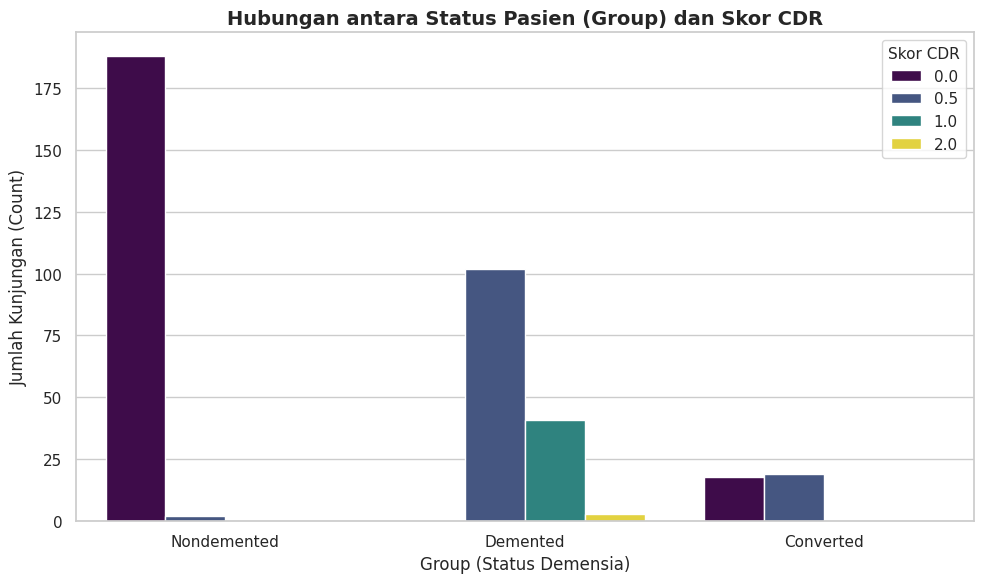

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Group', hue='CDR', palette='viridis')

plt.title('Hubungan antara Status Pasien (Group) dan Skor CDR', fontsize=14, fontweight='bold')
plt.xlabel('Group (Status Demensia)', fontsize=12)
plt.ylabel('Jumlah Kunjungan (Count)', fontsize=12)
plt.legend(title='Skor CDR', title_fontsize='11')

plt.tight_layout()
plt.show()

In [ ]:
df.loc[(df['Group'] == 'Converted') & (df['CDR'] == 0)]

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
33,OAS2_0018,OAS2_0018_MR1,Converted,1,0,F,R,87,14,1.0,30.0,0.0,1406,0.715,1.248
34,OAS2_0018,OAS2_0018_MR3,Converted,3,489,F,R,88,14,1.0,29.0,0.0,1398,0.713,1.255
36,OAS2_0020,OAS2_0020_MR1,Converted,1,0,M,R,80,20,1.0,29.0,0.0,1587,0.693,1.106
57,OAS2_0031,OAS2_0031_MR1,Converted,1,0,F,R,86,12,3.0,30.0,0.0,1430,0.718,1.227
58,OAS2_0031,OAS2_0031_MR2,Converted,2,446,F,R,88,12,3.0,30.0,0.0,1445,0.719,1.215
81,OAS2_0041,OAS2_0041_MR1,Converted,1,0,F,R,71,16,1.0,27.0,0.0,1289,0.771,1.362
82,OAS2_0041,OAS2_0041_MR2,Converted,2,756,F,R,73,16,1.0,28.0,0.0,1295,0.768,1.356
114,OAS2_0054,OAS2_0054_MR1,Converted,1,0,F,R,85,18,1.0,29.0,0.0,1264,0.701,1.388
194,OAS2_0092,OAS2_0092_MR1,Converted,1,0,F,R,83,12,2.0,28.0,0.0,1383,0.748,1.269
218,OAS2_0103,OAS2_0103_MR1,Converted,1,0,F,R,69,16,1.0,30.0,0.0,1404,0.750,1.250


In [ ]:
X_train_imputed.sample()

,median_imputer__MMSE,mode_imputer__SES,remainder__Subject ID,remainder__MRI ID,remainder__Visit,remainder__MR Delay,remainder__M/F,remainder__Hand,remainder__Age,remainder__EDUC,remainder__CDR,remainder__eTIV,remainder__nWBV,remainder__ASF,age_nWBV_ratio,educ_ses
261,29.0,1.0,OAS2_0127,OAS2_0127_MR1,1,0,M,R,79,18,0.0,1644,0.729,1.067,0.009228,18.0


In [ ]:
# Rate of change

X_train_imputed = X_train_imputed.sort_values(by=['remainder__Subject ID', 'remainder__Visit'])
# X_test_imputed = X_test_imputed.sort_values(by=['Subject ID', 'Visit'])

X_train_imputed['nWBV_Previous'] = X_train_imputed.groupby('remainder__Subject ID')['remainder__nWBV'].shift(1)
X_train_imputed['nWBV_Change'] = X_train_imputed['remainder__nWBV'] - X_train_imputed['nWBV_Previous']

X_train_imputed['MMSE_Previous'] = X_train_imputed.groupby('remainder__Subject ID')['median_imputer__MMSE'].shift(1)
X_train_imputed['MMSE_Change'] = X_train_imputed['median_imputer__MMSE'] - X_train_imputed['MMSE_Previous']

X_train_imputed['Days_Since_Last_Visit'] = X_train_imputed.groupby('remainder__Subject ID')['remainder__MR Delay'].shift(1)
X_train_imputed['Days_Between_Visits'] = X_train_imputed['remainder__MR Delay'] - X_train_imputed['Days_Since_Last_Visit']

X_train_imputed['nWBV_Yearly_Loss'] = (X_train_imputed['nWBV_Change'] / X_train_imputed['Days_Between_Visits']) * 365

X_train_imputed = X_train_imputed.drop(columns=['nWBV_Previous', 'MMSE_Previous', 'Days_Since_Last_Visit', 'Days_Between_Visits'])

In [ ]:
X_train_imputed['nWBV_Change'] = X_train_imputed['nWBV_Change'].fillna(0)
X_train_imputed['MMSE_Change'] = X_train_imputed['MMSE_Change'].fillna(0)
X_train_imputed['nWBV_Yearly_Loss'] = X_train_imputed['nWBV_Yearly_Loss'].fillna(0)

In [ ]:
X_train_imputed

,median_imputer__MMSE,mode_imputer__SES,remainder__Subject ID,remainder__MRI ID,remainder__Visit,remainder__MR Delay,remainder__M/F,remainder__Hand,remainder__Age,remainder__EDUC,remainder__CDR,remainder__eTIV,remainder__nWBV,remainder__ASF,age_nWBV_ratio,educ_ses,nWBV_Change,MMSE_Change,nWBV_Yearly_Loss
0,27.0,2.0,OAS2_0001,OAS2_0001_MR1,1,0,M,R,87,14,0.0,1987,0.696,0.883,0.008000,28.0,0.000,0.0,0.000000
1,30.0,2.0,OAS2_0001,OAS2_0001_MR2,2,457,M,R,88,14,0.0,2004,0.681,0.876,0.007739,28.0,-0.015,3.0,-0.011980
2,23.0,1.0,OAS2_0002,OAS2_0002_MR1,1,0,M,R,75,12,0.5,1678,0.736,1.046,0.009813,12.0,0.000,0.0,0.000000
3,28.0,1.0,OAS2_0002,OAS2_0002_MR2,2,560,M,R,76,12,0.5,1738,0.713,1.010,0.009382,12.0,-0.023,5.0,-0.014991
4,22.0,1.0,OAS2_0002,OAS2_0002_MR3,3,1895,M,R,80,12,0.5,1698,0.701,1.034,0.008762,12.0,-0.012,-6.0,-0.003281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,30.0,2.0,OAS2_0183,OAS2_0183_MR3,3,732,F,R,68,13,0.0,1506,0.740,1.165,0.010882,26.0,0.000,0.0,0.000000
364,30.0,2.0,OAS2_0183,OAS2_0183_MR4,4,2107,F,R,72,13,0.0,1510,0.723,1.162,0.010042,26.0,-0.017,0.0,-0.004513
367,28.0,1.0,OAS2_0185,OAS2_0185_MR1,1,0,M,R,80,16,0.5,1704,0.711,1.030,0.008887,16.0,0.000,0.0,0.000000
368,28.0,1.0,OAS2_0185,OAS2_0185_MR2,2,842,M,R,82,16,0.5,1693,0.694,1.037,0.008463,16.0,-0.017,0.0,-0.007369


### Data Transformation

In [ ]:
numerical_cols = X_train_imputed.select_dtypes(include=['float64', 'int64']).columns

print("--- Skewness of Features ---")
skew_scores = X_train_imputed[numerical_cols].skew().sort_values(ascending=False)
print(skew_scores)

--- Skewness of Features ---
remainder__CDR          1.484699
remainder__Visit        0.994819
remainder__MR Delay     0.908877
age_nWBV_ratio          0.526918
remainder__eTIV         0.427078
mode_imputer__SES       0.356397
remainder__nWBV         0.210430
remainder__Age          0.187800
educ_ses                0.133878
remainder__ASF          0.112904
remainder__EDUC        -0.180524
nWBV_Yearly_Loss       -1.749724
nWBV_Change            -1.835482
MMSE_Change            -2.130998
median_imputer__MMSE   -2.542071
dtype: float64


In [ ]:
X_train_imputed.columns

Index(['median_imputer__MMSE', 'mode_imputer__SES', 'remainder__Subject ID',
       'remainder__MRI ID', 'remainder__Visit', 'remainder__MR Delay',
       'remainder__M/F', 'remainder__Hand', 'remainder__Age',
       'remainder__EDUC', 'remainder__CDR', 'remainder__eTIV',
       'remainder__nWBV', 'remainder__ASF', 'age_nWBV_ratio', 'educ_ses',
       'nWBV_Change', 'MMSE_Change', 'nWBV_Yearly_Loss'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import PowerTransformer, StandardScaler

yeo_johnson_cols = [
    'remainder__MR Delay',
    'median_imputer__MMSE',
    'MMSE_Change',
    'nWBV_Change',
    'nWBV_Yearly_Loss'
]

yeo_johnson_transformer = PowerTransformer(method='yeo-johnson', standardize=False)

X_train_transformed = X_train_imputed.copy()

X_train_transformed[yeo_johnson_cols] = yeo_johnson_transformer.fit_transform(X_train_imputed[yeo_johnson_cols])

print("--- Skewness of Features ---")
skew_scores = X_train_transformed[yeo_johnson_cols].skew().sort_values(ascending=False)
print(skew_scores)


--- Skewness of Features ---
MMSE_Change             0.416292
nWBV_Yearly_Loss        0.111941
nWBV_Change             0.066705
remainder__MR Delay    -0.319083
median_imputer__MMSE   -0.681304
dtype: float64


### Feature Scalling

In [ ]:
X_train_transformed.head(3)

,median_imputer__MMSE,mode_imputer__SES,remainder__Subject ID,remainder__MRI ID,remainder__Visit,remainder__MR Delay,remainder__M/F,remainder__Hand,remainder__Age,remainder__EDUC,remainder__CDR,remainder__eTIV,remainder__nWBV,remainder__ASF,age_nWBV_ratio,educ_ses,nWBV_Change,MMSE_Change,nWBV_Yearly_Loss
0,6.989111e+09,2.0,OAS2_0001,OAS2_0001_MR1,1,0.000000,M,R,87,14,0.0,1987,0.696,0.883,0.008000,28.0,0.000000,0.000000,0.000000
1,1.484835e+10,2.0,OAS2_0001,OAS2_0001_MR2,2,10.018426,M,R,88,14,0.0,2004,0.681,0.876,0.007739,28.0,-0.011258,3.748965,-0.008321
2,2.232492e+09,1.0,OAS2_0002,OAS2_0002_MR1,1,0.000000,M,R,75,12,0.5,1678,0.736,1.046,0.009813,12.0,0.000000,0.000000,0.000000


In [ ]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = yeo_johnson_cols + [
    'remainder__eTIV',
    'remainder__nWBV',
    'remainder__Age',
    'remainder__ASF',
    'educ_ses',
    'remainder__EDUC',
    'age_nWBV_ratio'
]

scaler = StandardScaler()

X_train_scaled = X_train_transformed.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train_transformed[cols_to_scale])

X_train_scaled.head(3)

,median_imputer__MMSE,mode_imputer__SES,remainder__Subject ID,remainder__MRI ID,remainder__Visit,remainder__MR Delay,remainder__M/F,remainder__Hand,remainder__Age,remainder__EDUC,remainder__CDR,remainder__eTIV,remainder__nWBV,remainder__ASF,age_nWBV_ratio,educ_ses,nWBV_Change,MMSE_Change,nWBV_Yearly_Loss
0,-0.610875,2.0,OAS2_0001,OAS2_0001_MR1,1,-1.213028,M,R,1.249435,-0.238911,0.0,2.878763,-0.914885,-2.288568,-1.215499,-0.311026,0.517764,0.069923,0.495604
1,1.053797,2.0,OAS2_0001,OAS2_0001_MR2,2,0.497694,M,R,1.380160,-0.238911,0.0,2.977671,-1.333252,-2.340500,-1.423649,-0.311026,-1.134978,2.396274,-1.666873
2,-1.618379,1.0,OAS2_0002,OAS2_0002_MR1,1,-1.213028,M,R,-0.319262,-0.918631,0.5,1.080950,0.200761,-1.079289,0.228636,-1.522153,0.517764,0.069923,0.495604


### Data encoding

There are four categorical features after we deleted the 'Hand' column. They are 'Group', 'M/F', 'SES', 'CDR'. For 'Group' and 'M/F' features, we apply one hot encoding, while 'SES' and 'CDR', since their order is meaningful, we apply ordinal encoding.

In [ ]:
X_train_scaled.columns

Index(['median_imputer__MMSE', 'mode_imputer__SES', 'remainder__Subject ID',
       'remainder__MRI ID', 'remainder__Visit', 'remainder__MR Delay',
       'remainder__M/F', 'remainder__Hand', 'remainder__Age',
       'remainder__EDUC', 'remainder__CDR', 'remainder__eTIV',
       'remainder__nWBV', 'remainder__ASF', 'age_nWBV_ratio', 'educ_ses',
       'nWBV_Change', 'MMSE_Change', 'nWBV_Yearly_Loss'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

print("Target classes mapping:", le.classes_)

Target classes mapping: ['Converted' 'Demented' 'Nondemented']


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')

X_train_mf = ohe.fit_transform(X_train_scaled[['remainder__M/F']])

ordinal = OrdinalEncoder().set_output(transform='pandas')

# cols ordinal
cols_ordinal = ['mode_imputer__SES', 'remainder__CDR']
X_train_ordinal = ordinal.fit_transform(X_train_scaled[cols_ordinal])

cols_to_drop = ['remainder__M/F', 'mode_imputer__SES', 'remainder__CDR']

X_train_encoded = pd.concat([
    X_train_scaled.drop(columns=cols_to_drop),
    X_train_mf,
    X_train_ordinal
], axis=1)

X_train_encoded.head()

,median_imputer__MMSE,remainder__Subject ID,remainder__MRI ID,remainder__Visit,remainder__MR Delay,remainder__Hand,remainder__Age,remainder__EDUC,remainder__eTIV,remainder__nWBV,remainder__ASF,age_nWBV_ratio,educ_ses,nWBV_Change,MMSE_Change,nWBV_Yearly_Loss,remainder__M/F_M,mode_imputer__SES,remainder__CDR
0,-0.610875,OAS2_0001,OAS2_0001_MR1,1,-1.213028,R,1.249435,-0.238911,2.878763,-0.914885,-2.288568,-1.215499,-0.311026,0.517764,0.069923,0.495604,1.0,1.0,0.0
1,1.053797,OAS2_0001,OAS2_0001_MR2,2,0.497694,R,1.380160,-0.238911,2.977671,-1.333252,-2.340500,-1.423649,-0.311026,-1.134978,2.396274,-1.666873,1.0,1.0,0.0
2,-1.618379,OAS2_0002,OAS2_0002_MR1,1,-1.213028,R,-0.319262,-0.918631,1.080950,0.200761,-1.079289,0.228636,-1.522153,0.517764,0.069923,0.495604,1.0,0.0,1.0
3,-0.171704,OAS2_0002,OAS2_0002_MR2,2,0.585440,R,-0.188537,-0.918631,1.430040,-0.440735,-1.346369,-0.115212,-1.522153,-1.685609,4.271022,-1.993656,1.0,0.0,1.0
4,-1.746182,OAS2_0002,OAS2_0002_MR3,3,1.171889,R,0.334362,-0.918631,1.197313,-0.775429,-1.168316,-0.608246,-1.522153,-0.878873,-2.640113,-0.272020,1.0,0.0,1.0


### Feature Selection

#### Manual feature selection

Based on the previous explorartion, we found that 'Hand' column only has one value 'R' and 'eTIV' and 'ASF' have high-correlation: -0.99. Thus, we drop 'Hand' and 'ASF' columns.

In [ ]:
X_train_encoded.drop(columns=['remainder__Hand', 'remainder__ASF'], inplace=True)

#### Statistical Hypothesis Testing for Feature Selection (Filter Method)

Following the manual elimination of features based on domain knowledge and indications of extreme multicollinearity (such as dropping the `Hand` feature due to zero variance and `ASF` due to perfect collinearity with `eTIV`), the next step is to conduct objective feature selection using inferential statistics (Filter Method).

This phase aims to evaluate the strength of the dependency between each independent feature and the target variable (`Group`). This ensures the model is trained exclusively on predictors that carry valid informational signals, effectively filtering out potential noise.

The statistical tests are segregated based on the data types:
1. **Numerical Features (Clinical & Longitudinal):** Evaluated using the **ANOVA F-test (`f_classif`)**. This test assesses whether there is a statistically significant difference in the mean variances of these continuous features across the three distinct diagnostic groups.
2. **Nominal Features (Unordered Categorical):** Evaluated using the **Chi-Square Test (`chi2`)**. This measures the independence of the frequency distribution between the feature categories (e.g., *Gender*) and the target classes.
3. **Ordinal Features (Ordered Categorical):** Evaluated using the ANOVA F-score to estimate the significance of their categorical hierarchy relative to the target progression.

**Acceptance Criterion:** Features are evaluated based on their test scores (F-Score or Chi-Square Score) and their probability of significance (*P-Value*). A feature with a $P\text{-}Value > 0.05$ indicates a failure to reject the null hypothesis ($H_0$), meaning the feature has no statistically significant relationship with the patient's dementia progression and is a candidate for removal.

In [ ]:
X_train_encoded.columns

Index(['median_imputer__MMSE', 'remainder__Subject ID', 'remainder__MRI ID',
       'remainder__Visit', 'remainder__MR Delay', 'remainder__Age',
       'remainder__EDUC', 'remainder__eTIV', 'remainder__nWBV',
       'age_nWBV_ratio', 'educ_ses', 'nWBV_Change', 'MMSE_Change',
       'nWBV_Yearly_Loss', 'remainder__M/F_M', 'mode_imputer__SES',
       'remainder__CDR'],
      dtype='object')

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

numerical_features = [
    'median_imputer__MMSE', 'remainder__Visit', 'remainder__MR Delay', 'remainder__Age', 'remainder__EDUC', 'remainder__eTIV',
    'remainder__nWBV', 'age_nWBV_ratio', 'educ_ses', 'nWBV_Change', 'MMSE_Change', 'nWBV_Yearly_Loss',
]

X = X_train_encoded[numerical_features].copy()
y = y_train_encoded.copy()

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Attribute': numerical_features,
    'F-Score': selector.scores_,
    'P-Value': selector.pvalues_
})

feature_scores['P-Value'] = feature_scores['P-Value'].apply(lambda x: f"{x:.7f}")

feature_scores = feature_scores.sort_values(by='F-Score', ascending=False).reset_index(drop=True)

print("--- Hasil Uji f_classif (Feature Selection) ---")
print(feature_scores)

--- Hasil Uji f_classif (Feature Selection) ---
               Attribute     F-Score    P-Value
0   median_imputer__MMSE  160.290928  0.0000000
1        remainder__nWBV   14.499310  0.0000010
2        remainder__EDUC   11.981794  0.0000099
3               educ_ses    7.454148  0.0006927
4         remainder__Age    5.541829  0.0043312
5         age_nWBV_ratio    4.135730  0.0169118
6       nWBV_Yearly_Loss    2.837022  0.0601733
7       remainder__Visit    2.582351  0.0772758
8            nWBV_Change    2.236079  0.1086551
9            MMSE_Change    2.187818  0.1139477
10   remainder__MR Delay    1.597625  0.2040935
11       remainder__eTIV    0.211583  0.8094227


In [ ]:
from scipy.stats import spearmanr
from sklearn.feature_selection import chi2

nominal_cols = ['remainder__M/F_M']
ordinal_cols = ['mode_imputer__SES','remainder__CDR']

# Target
y = y_train.copy()

# 2. Uji Nominal (Chi-Square)
selector_chi = SelectKBest(score_func=chi2, k='all')
selector_chi.fit(X_train_encoded[nominal_cols], y)

df_nom = pd.DataFrame({
    'Attribute': nominal_cols,
    'Score': selector_chi.scores_,
    'P-Value': selector_chi.pvalues_,
    'Method': 'Chi-Square'
})

# 3. Uji Ordinal (Spearman Rank Correlation)
spearman_list = []
for col in ordinal_cols:
    # Menghitung koefisien korelasi dan p-value
    corr, p_val = spearmanr(X_train_encoded[col], y)
    spearman_list.append({
        'Attribute': col,
        'Score': corr,
        'P-Value': p_val,
        'Method': 'Spearman'
    })

df_ord = pd.DataFrame(spearman_list)

# 4. Gabungkan dan Format
final_report = pd.concat([df_nom, df_ord], axis=0)
final_report['P-Value'] = final_report['P-Value'].apply(lambda x: f"{x:.7f}")
# Mengurutkan berdasarkan nilai absolut Score agar korelasi negatif kuat tetap di atas
final_report['Abs_Score'] = final_report['Score'].abs()
final_report = final_report.sort_values(by='Abs_Score', ascending=False).reset_index(drop=True)
final_report = final_report.drop(columns=['Abs_Score'])

print("Hasil Uji Fitur Kategorik terhadap Group (Nominal & Ordinal)")
print(final_report)

Hasil Uji Fitur Kategorik terhadap Group (Nominal & Ordinal)
           Attribute      Score    P-Value      Method
0   remainder__M/F_M  14.614022  0.0006708  Chi-Square
1     remainder__CDR  -0.762974  0.0000000    Spearman
2  mode_imputer__SES   0.103992  0.0706677    Spearman


### Data Augmentation

In [ ]:
features_to_keep = [
    'median_imputer__MMSE', 'remainder__nWBV', 'remainder__EDUC',
    'educ_ses', 'remainder__Age', 'age_nWBV_ratio', 'remainder__M/F_M', 'nWBV_Yearly_Loss'
]

X_train_final = X_train_encoded[features_to_keep]
y_train_final = y_train_encoded

categorical_features_indices = [X_train_final.columns.get_loc(col) for col in ['remainder__M/F_M']]

print(f"Categorical features found at indices: {categorical_features_indices}")

Categorical features found at indices: [6]


In [ ]:
X_train_final.head()

,median_imputer__MMSE,remainder__nWBV,remainder__EDUC,educ_ses,remainder__Age,age_nWBV_ratio,remainder__M/F_M,nWBV_Yearly_Loss
0,-0.610875,-0.914885,-0.238911,-0.311026,1.249435,-1.215499,1.0,0.495604
1,1.053797,-1.333252,-0.238911,-0.311026,1.380160,-1.423649,1.0,-1.666873
2,-1.618379,0.200761,-0.918631,-1.522153,-0.319262,0.228636,1.0,0.495604
3,-0.171704,-0.440735,-0.918631,-1.522153,-0.188537,-0.115212,1.0,-1.993656
4,-1.746182,-0.775429,-0.918631,-1.522153,0.334362,-0.608246,1.0,-0.272020


In [ ]:
from imblearn.over_sampling import SMOTENC

smotenc = SMOTENC(
    categorical_features=categorical_features_indices,
    random_state=0, # Using your optimized RS from earlier
    sampling_strategy='auto'
)

X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train_final, y_train_final)

print("--- Distribution AFTER SMOTE-NC ---")
unique, counts = np.unique(y_train_resampled, return_counts=True)
dist = dict(zip(le.inverse_transform(unique), counts))
for cls, count in dist.items():
    print(f"{cls}: {count} samples")

X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train_final.columns)

--- Distribution AFTER SMOTE-NC ---
Converted: 161 samples
Demented: 161 samples
Nondemented: 161 samples


## Full Preprocessing Pipeline

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin

from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif

**1st improvement**

Splitting data before moving into preprocessing process

**2nd improvement**
Using StratifiedGroupKFold to make sure that patient with the same id isn't ended on the different split. It also works on non balanced data


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

df = df.sort_values(by=['Subject ID', 'Visit']).reset_index(drop=True)

X = df.drop(columns=['Group'])
y = df['Group']
groups = df['Subject ID']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

train_idx, test_idx = next(sgkf.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Data splitting result:")
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Data splitting result:
Training set size: 303
Testing set size: 70


In [ ]:
# Simpan versi rawnya
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

In [ ]:
class OutlierRemover(BaseEstimator, TransformerMixin):
  # A transformer function to remove outliers using IQR method
    def __init__(self, lower_quantile=0.05, upper_quantile=0.95):
      self.lower_quantile = lower_quantile
      self.upper_quantile = upper_quantile

    def fit(self, X, y=None):
      self.lower_bounds_ = np.nanquantile(X, self.lower_quantile, axis=0)
      self.upper_bounds_ = np.nanquantile(X. self.upper_quantile, axis=0)
      return self

    def transform(self, X, y=None):
      X_clipped = np.clip(X, self.lower_bounds_, self.upper_bounds_)
      return X_clipped


**3rd improvement**

Adding new features related to dataset's longitudinal's nature

In [ ]:
def create_rate_of_change(df):
    df_sorted = df.copy()

    df_sorted['nWBV_Previous'] = df_sorted.groupby('Subject ID')['nWBV'].shift(1)
    df_sorted['nWBV_Change'] = df_sorted['nWBV'] - df_sorted['nWBV_Previous']

    df_sorted['MMSE_Previous'] = df_sorted.groupby('Subject ID')['MMSE'].shift(1)
    df_sorted['MMSE_Change'] = df_sorted['MMSE'] - df_sorted['MMSE_Previous']

    df_sorted['CDR_Previous'] = df_sorted.groupby('Subject ID')['CDR'].shift(1)
    df_sorted['CDR_Change'] = df_sorted['CDR'] - df_sorted['CDR_Previous']

    df_sorted['Days_Since_Last_Visit'] = df_sorted.groupby('Subject ID')['MR Delay'].shift(1)
    df_sorted['Days_Between_Visits'] = (
        df_sorted['MR Delay'] - df_sorted['Days_Since_Last_Visit']
    )

    df_sorted['nWBV_Yearly_Change'] = np.where(
        df_sorted['Days_Between_Visits'] == 0, 0,
        (df_sorted['nWBV_Change'] / df_sorted['Days_Between_Visits']) * 365
    )
    df_sorted['MMSE_Yearly_Change'] = np.where(
        df_sorted['Days_Between_Visits'] == 0, 0,
        (df_sorted['MMSE_Change'] / df_sorted['Days_Between_Visits']) * 365
    )

    # === Fitur agregat ===
    df_sorted['CDR_ever_nonzero'] = (
        df_sorted.groupby('Subject ID')['CDR']
        .transform(lambda x: x.expanding().max()) > 0
    ).astype(int)

    df_sorted['MMSE_drop_so_far'] = (
        df_sorted.groupby('Subject ID')['MMSE']
        .transform(lambda x: x.expanding().max())
        - df_sorted['MMSE']
    )

    df_sorted['nWBV_total_decline'] = (
        df_sorted.groupby('Subject ID')['nWBV']
        .transform(lambda x: x.expanding().max())
        - df_sorted['nWBV']
    )

    df_sorted['visit_number'] = (
        df_sorted.groupby('Subject ID').cumcount() + 1
    )
    df_sorted['is_followup'] = (
        df_sorted['visit_number'] > 1
    ).astype(int)

    # nWBV decline per tahun — Converted mungkin decline lebih cepat
    # dari Nondemented meski total visit lebih sedikit
    df_sorted['nWBV_decline_rate'] = np.where(
        df_sorted['MR Delay'] == 0, 0,
        (df_sorted['nWBV_total_decline'] / df_sorted['MR Delay']) * 365
    )

    # Kombinasi: CDR borderline + nWBV sudah menyusut
    # Ini profil khas Converted: CDR mulai naik, otak sudah menyusut
    df_sorted['at_risk_profile'] = (
        (df_sorted['CDR_ever_nonzero'] == 1) &
        (df_sorted['nWBV_total_decline'] > df_sorted['nWBV_total_decline'].median())
    ).astype(int)

    # Fill NaN visit pertama
    fill_zero_cols = [
        'nWBV_Change', 'MMSE_Change', 'CDR_Change',
        'nWBV_Yearly_Change', 'MMSE_Yearly_Change', 'CDR_Previous', 'MMSE_drop_so_far'
    ]
    df_sorted[fill_zero_cols] = df_sorted[fill_zero_cols].fillna(0)

    return df_sorted.drop(columns=[
        'nWBV_Previous', 'MMSE_Previous',
        'Days_Since_Last_Visit', 'Days_Between_Visits'
    ])

In [ ]:
X_train = create_rate_of_change(X_train)
X_test = create_rate_of_change(X_test)

In [ ]:
X_train.columns

Index(['Subject ID', 'MRI ID', 'Visit', 'MR Delay', 'M/F', 'Hand', 'Age',
       'EDUC', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'nWBV_Change',
       'MMSE_Change', 'CDR_Previous', 'CDR_Change', 'nWBV_Yearly_Change',
       'MMSE_Yearly_Change', 'CDR_ever_nonzero', 'MMSE_drop_so_far',
       'nWBV_total_decline', 'visit_number', 'is_followup',
       'nWBV_decline_rate', 'at_risk_profile'],
      dtype='object')

In [ ]:
# drop unused columns
cols_to_drop = ['Subject ID', 'MRI ID']
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

In [ ]:
class RowFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()

        # Buat fitur rasio
        if 'Age' in X_copy.columns and 'nWBV' in X_copy.columns:
            X_copy['age_nWBV_ratio'] = X_copy['nWBV'] / X_copy['Age']

        if 'EDUC' in X_copy.columns and 'SES' in X_copy.columns:
            X_copy['educ_ses'] = X_copy['EDUC'] * X_copy['SES']

        if 'CDR' in X_copy.columns and 'MMSE' in X_copy.columns:
            X_copy['CDR_x_MMSE'] = X_copy['CDR'] * X_copy['MMSE']

        # nWBV tinggi tapi CDR sudah naik = Converted early stage
        if 'CDR_ever_nonzero' in X_copy.columns and 'nWBV' in X_copy.columns:
            X_copy['nWBV_x_CDR_risk'] = X_copy['nWBV'] * X_copy['CDR_ever_nonzero']

        # Age + CDR interaction — lansia dengan CDR naik lebih berisiko Demented
        if 'Age' in X_copy.columns and 'CDR_ever_nonzero' in X_copy.columns:
            X_copy['age_x_CDR_risk'] = X_copy['Age'] * X_copy['CDR_ever_nonzero']

        return X_copy

In [ ]:
imputer_step = ColumnTransformer(
    transformers=[
        ('mmse_imputer', SimpleImputer(strategy='median'), ['MMSE']),
        ('ses_imputer', SimpleImputer(strategy='most_frequent'), ['SES'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [ ]:
imputer_step2 = FunctionTransformer(
    lambda X: X.fillna(0)
)

In [ ]:
yeo_cols = [
    'MR Delay', 'MMSE', 'MMSE_Change', 'MMSE_Yearly_Change',
    'nWBV_Change', 'nWBV_Yearly_Change', 'nWBV_total_decline',
    'nWBV_decline_rate', 'MMSE_drop_so_far',
    'educ_ses', 'age_nWBV_ratio',
    'CDR_Change', 'CDR_Previous',
    'CDR_x_MMSE',
    'nWBV_x_CDR_risk',
    'age_x_CDR_risk']

scale_cols = [
    'eTIV', 'nWBV', 'Age', 'EDUC', 'Visit'
]
ohe_cols = ['M/F']
ordinal_cols = ['SES','CDR']
passthrough_cols = [
    'CDR_ever_nonzero',
    'at_risk_profile',
]

In [ ]:
prep_step = ColumnTransformer(
    transformers=[
        ('yeo_lane',      PowerTransformer(method='yeo-johnson'), yeo_cols),
        ('scale_lane',    StandardScaler(),                        scale_cols),
        ('ohe_lane',      OneHotEncoder(drop='first', sparse_output=False), ohe_cols),
        ('ordinal_lane',  OrdinalEncoder(),                        ordinal_cols),
        ('pass_lane',     'passthrough',                           passthrough_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [ ]:
num_selection_cols = [
    'MR Delay', 'MMSE', 'MMSE_Change', 'MMSE_Yearly_Change',
    'nWBV_Change', 'nWBV_Yearly_Change',
    'nWBV_total_decline', 'nWBV_decline_rate',
    'MMSE_drop_so_far',
    'eTIV', 'nWBV', 'Age', 'EDUC', 'Visit',
    'educ_ses', 'age_nWBV_ratio',
    'CDR_Change', 'CDR_Previous', 'CDR_x_MMSE',
    'nWBV_x_CDR_risk',
    'age_x_CDR_risk'
]
nom_selection_cols = ['M/F_M']
ord_selection_cols = ['SES', 'CDR']         # CDR tetap di ordinal selection
pass_selection_cols = [                     # binary fitur → pakai chi2
    'CDR_ever_nonzero',
    'at_risk_profile'
]

In [ ]:
def manual_feature_drop(X):
    to_drop = [
        'Hand', 'ASF',
        # 'is_followup',
        # 'visit_number',
    ]
    return X.drop(columns=[c for c in to_drop if c in X.columns], errors='ignore')

In [ ]:
from scipy.stats import spearmanr

def spearman_scorer(X, y):
    scores = []
    pvalues = []
    for i in range(X.shape[1]):
        corr, pval = spearmanr(X[:, i], y)
        scores.append(abs(corr))
        pvalues.append(pval)
    return np.array(scores), np.array(pvalues)

In [ ]:
from sklearn.feature_selection import SelectFpr, f_classif, chi2, GenericUnivariateSelect

In [ ]:
selection_step = ColumnTransformer(
    transformers=[
        ('num_select',  SelectFpr(score_func=f_classif, alpha=0.05),                        num_selection_cols),
        ('nom_select',  SelectFpr(score_func=chi2,      alpha=0.05),                        nom_selection_cols),
        ('ord_select',  GenericUnivariateSelect(score_func=spearman_scorer, mode='fpr', param=0.05), ord_selection_cols),
        ('pass_select', SelectFpr(score_func=chi2,      alpha=0.05),                        pass_selection_cols)
    ],
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [ ]:
pipeline_no_smote = Pipeline([
    ('imputation', imputer_step),
    ('row_features', RowFeatureEngineer()),
    ('preprocessing', prep_step),
    ('imputation2',   imputer_step2),
    ('manual_drop', FunctionTransformer(manual_feature_drop)),
    ('selection', selection_step)
])

In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

X_train_preprocessed = pipeline_no_smote.fit_transform(X_train, y_train_encoded)
X_test_preprocessed = pipeline_no_smote.transform(X_test)


In [ ]:
# Test step by step
try:
    out1 = pipeline_no_smote['imputation'].fit_transform(X_train)
    print("✅ imputation OK:", out1.shape)
except Exception as e:
    print("❌ imputation error:", e)

try:
    out2 = pipeline_no_smote['row_features'].fit_transform(out1)
    print("✅ row_features OK:", out2.shape)
except Exception as e:
    print("❌ row_features error:", e)

try:
    out3 = pipeline_no_smote['preprocessing'].fit_transform(out2)
    print("✅ preprocessing OK:", out3.shape)
    print("Kolom:", out3.columns.tolist())
except Exception as e:
    print("❌ preprocessing error:", e)

try:
    out4 = pipeline_no_smote['manual_drop'].fit_transform(out3)
    print("✅ manual_drop OK:", out4.shape)
except Exception as e:
    print("❌ manual_drop error:", e)

try:
    out5 = pipeline_no_smote['selection'].fit_transform(out4, y_train_encoded)
    print("✅ selection OK:", out5.shape)
except Exception as e:
    print("❌ selection error:", e)

✅ imputation OK: (303, 25)
✅ row_features OK: (303, 30)
✅ preprocessing OK: (303, 26)
Kolom: ['MR Delay', 'MMSE', 'MMSE_Change', 'MMSE_Yearly_Change', 'nWBV_Change', 'nWBV_Yearly_Change', 'nWBV_total_decline', 'nWBV_decline_rate', 'MMSE_drop_so_far', 'educ_ses', 'age_nWBV_ratio', 'CDR_Change', 'CDR_Previous', 'CDR_x_MMSE', 'nWBV_x_CDR_risk', 'age_x_CDR_risk', 'eTIV', 'nWBV', 'Age', 'EDUC', 'Visit', 'M/F_M', 'SES', 'CDR', 'CDR_ever_nonzero', 'at_risk_profile']
✅ manual_drop OK: (303, 26)
✅ selection OK: (303, 16)


In [ ]:
display(X_train_preprocessed.head())

,MMSE,MMSE_drop_so_far,nWBV,Age,EDUC,educ_ses,age_nWBV_ratio,CDR_Change,CDR_Previous,CDR_x_MMSE,nWBV_x_CDR_risk,age_x_CDR_risk,M/F_M,CDR,CDR_ever_nonzero,at_risk_profile
0,-0.610875,-0.567196,-0.914885,1.249435,-0.238911,-0.213122,-1.302941,-0.175348,-0.542957,-0.852356,-0.866473,-0.866737,1.0,0.0,0,0
1,1.053797,-0.567196,-1.333252,1.380160,-0.238911,-0.213122,-1.574906,-0.175348,-0.542957,-0.852356,-0.866473,-0.866737,1.0,0.0,0,0
2,-1.618379,-0.567196,0.200761,-0.319262,-0.918631,-1.705509,0.321496,-0.175348,-0.542957,1.065594,1.179570,1.147421,1.0,1.0,1,0
3,-0.171704,-0.567196,-0.440735,-0.188537,-0.918631,-1.705509,-0.026936,-0.175348,1.822919,1.147117,1.148535,1.151250,1.0,1.0,1,1
4,-1.746182,1.921432,-0.775429,0.334362,-0.918631,-1.705509,-0.566772,-0.175348,1.822919,1.046585,1.131907,1.165992,1.0,1.0,1,1


In [ ]:
selection_layer = pipeline_no_smote.named_steps['selection']

In [ ]:
num_transformer = selection_layer.named_transformers_['num_select']
df_num_scores = pd.DataFrame({
    'Attribute': num_selection_cols,
    'F-Score': num_transformer.scores_,
    'P-Value': num_transformer.pvalues_,
    'Method': 'ANOVA'
})

In [ ]:
nom_transformer = selection_layer.named_transformers_['nom_select']
df_nom_scores = pd.DataFrame({
    'Attribute': nom_selection_cols,
    'Score': nom_transformer.scores_,
    'P-Value': nom_transformer.pvalues_,
    'Method': 'Chi-Square'
})

In [ ]:
ord_trans = selection_layer.named_transformers_['ord_select']
df_ord_scores = pd.DataFrame({
    'Attribute': ord_selection_cols,
    'Score': ord_trans.scores_,
    'P-Value': ord_trans.pvalues_,
    'Method': 'Spearman'
})

In [ ]:
pass_trans = selection_layer.named_transformers_['pass_select']
df_pass_scores = pd.DataFrame({
    'Attribute': pass_selection_cols,
    'Score': pass_trans.scores_,
    'P-Value': pass_trans.pvalues_,
    'Method': 'Chi-square'
})

In [ ]:
report_selection = pd.concat([df_num_scores, df_nom_scores, df_ord_scores, df_pass_scores], axis=0)
report_selection['P-Value'] = report_selection['P-Value'].apply(lambda x: f"{x:.7f}")
report_selection = report_selection.sort_values(by='P-Value').reset_index(drop=True)

print("--- Laporan Seleksi Fitur di Dalam Pipeline ---")
display(report_selection)

--- Laporan Seleksi Fitur di Dalam Pipeline ---


,Attribute,F-Score,P-Value,Method,Score
0,at_risk_profile,NaN,0.0000000,Chi-square,73.236802
1,MMSE,160.290928,0.0000000,ANOVA,NaN
2,CDR,NaN,0.0000000,Spearman,0.762974
3,age_x_CDR_risk,869.280747,0.0000000,ANOVA,NaN
4,nWBV_x_CDR_risk,882.321909,0.0000000,ANOVA,NaN
5,CDR_x_MMSE,1079.102126,0.0000000,ANOVA,NaN
6,CDR_Previous,96.734687,0.0000000,ANOVA,NaN
7,CDR_ever_nonzero,NaN,0.0000000,Chi-square,148.093319
8,nWBV,14.499310,0.0000010,ANOVA,NaN
9,CDR_Change,14.351954,0.0000011,ANOVA,NaN


In [ ]:
final_feature_names = X_train_preprocessed.columns.tolist()
print(final_feature_names)
cat_indices = [
    i for i, col in enumerate(final_feature_names)
    if col in ['M/F_M', 'CDR_ever_nonzero', 'at_risk_profile', 'SES', 'CDR']
]
print("Cat indices:", cat_indices)
print("Kolom kategorikal:", [final_feature_names[i] for i in cat_indices])

['MMSE', 'MMSE_drop_so_far', 'nWBV', 'Age', 'EDUC', 'educ_ses', 'age_nWBV_ratio', 'CDR_Change', 'CDR_Previous', 'CDR_x_MMSE', 'nWBV_x_CDR_risk', 'age_x_CDR_risk', 'M/F_M', 'CDR', 'CDR_ever_nonzero', 'at_risk_profile']
Cat indices: [12, 13, 14, 15]
Kolom kategorikal: ['M/F_M', 'CDR', 'CDR_ever_nonzero', 'at_risk_profile']


In [ ]:
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

Label encoding:
  0 = Converted
  1 = Demented
  2 = Nondemented


In [ ]:
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

smote_nc = SMOTENC(
    categorical_features=cat_indices,
    random_state=0,
    sampling_strategy='auto'
)

pipeline_with_smote = ImbPipeline([
    ('imputation',    imputer_step),
    ('row_features',  RowFeatureEngineer()),
    ('imputation2',   FunctionTransformer(lambda X: X.fillna(0))),
    ('preprocessing', prep_step),
    ('manual_drop',   FunctionTransformer(manual_feature_drop)),
    ('selection',     selection_step),  # ← ada
    ('smotenc',       smote_nc)
])

X_train_balanced, y_train_balanced = pipeline_with_smote.fit_resample(
    X_train, y_train_encoded
)

print("\n--- Distribusi Kelas Setelah Augmentasi (SMOTE-NC) ---")
unique, counts = np.unique(y_train_balanced, return_counts=True)
target_names = le.inverse_transform(unique)
for name, count in zip(target_names, counts):
    print(f"{name}: {count} sampel")

display(X_train_balanced.head())


--- Distribusi Kelas Setelah Augmentasi (SMOTE-NC) ---
Converted: 161 sampel
Demented: 161 sampel
Nondemented: 161 sampel


,MMSE,MMSE_drop_so_far,nWBV,Age,EDUC,educ_ses,age_nWBV_ratio,CDR_Change,CDR_Previous,CDR_x_MMSE,nWBV_x_CDR_risk,age_x_CDR_risk,M/F_M,CDR,CDR_ever_nonzero,at_risk_profile
0,-0.610875,-0.567196,-0.914885,1.249435,-0.238911,-0.213122,-1.302941,-0.175348,-0.542957,-0.852356,-0.866473,-0.866737,1.0,0.0,0,0
1,1.053797,-0.567196,-1.333252,1.380160,-0.238911,-0.213122,-1.574906,-0.175348,-0.542957,-0.852356,-0.866473,-0.866737,1.0,0.0,0,0
2,-1.618379,-0.567196,0.200761,-0.319262,-0.918631,-1.705509,0.321496,-0.175348,-0.542957,1.065594,1.179570,1.147421,1.0,1.0,1,0
3,-0.171704,-0.567196,-0.440735,-0.188537,-0.918631,-1.705509,-0.026936,-0.175348,1.822919,1.147117,1.148535,1.151250,1.0,1.0,1,1
4,-1.746182,1.921432,-0.775429,0.334362,-0.918631,-1.705509,-0.566772,-0.175348,1.822919,1.046585,1.131907,1.165992,1.0,1.0,1,1


In [ ]:
X_train_balanced

,MMSE,MMSE_drop_so_far,nWBV,Age,EDUC,educ_ses,age_nWBV_ratio,CDR_Change,CDR_Previous,CDR_x_MMSE,nWBV_x_CDR_risk,age_x_CDR_risk,M/F_M,CDR,CDR_ever_nonzero,at_risk_profile
0,-0.610875,-0.567196,-0.914885,1.249435,-0.238911,-0.213122,-1.302941,-0.175348,-0.542957,-0.852356,-0.866473,-0.866737,1.0,0.0,0,0
1,1.053797,-0.567196,-1.333252,1.380160,-0.238911,-0.213122,-1.574906,-0.175348,-0.542957,-0.852356,-0.866473,-0.866737,1.0,0.0,0,0
2,-1.618379,-0.567196,0.200761,-0.319262,-0.918631,-1.705509,0.321496,-0.175348,-0.542957,1.065594,1.179570,1.147421,1.0,1.0,1,0
3,-0.171704,-0.567196,-0.440735,-0.188537,-0.918631,-1.705509,-0.026936,-0.175348,1.822919,1.147117,1.148535,1.151250,1.0,1.0,1,1
4,-1.746182,1.921432,-0.775429,0.334362,-0.918631,-1.705509,-0.566772,-0.175348,1.822919,1.046585,1.131907,1.165992,1.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,0.615096,-0.567196,1.175266,-0.734370,-0.698683,1.315715,0.996965,-0.175348,-0.542957,1.165970,1.224671,1.134212,0.0,1.0,1,0
479,0.163981,-0.567196,1.086159,-0.381466,-0.632678,1.362287,0.689973,-0.175348,-0.542957,1.154184,1.220667,1.145540,0.0,1.0,1,0
480,0.230951,-0.567196,-0.067503,-0.992088,0.170895,-1.035620,0.759720,-0.175348,1.822919,1.157481,1.166598,1.126380,1.0,1.0,1,1
481,-1.861096,-0.567196,0.173174,-1.861244,0.309308,0.689505,1.567754,-0.175348,-0.542957,1.001071,1.178252,1.097068,1.0,1.0,1,0


In [ ]:
X_train.shape

(303, 25)

In [ ]:
X_train_balanced.shape

(483, 16)

# Model A (Jangan di-run)

In [ ]:
X_train, y_train = X_train_balanced.copy(), y_train_balanced.copy()
X_test, y_test = X_test_preprocessed.copy(), y_test_encoded.copy()

In [ ]:
!pip install xgboost

#### Default run

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

gnb_model = GaussianNB()
xgb_model = XGBClassifier()
dt_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()
gb_model = GradientBoostingClassifier()
voting_model = VotingClassifier(
    estimators=[('gnb', gnb_model), ('rf', rf_model), ('xgb', xgb_model), ('dt', dt_model), ('gb', gb_model)],
    voting='soft'
)

In [ ]:
models = {
    "Gaussian NB": gnb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Gradient Boosting": gb_model,
    "Voting Ensemble": voting_model
}

# Training
print("Memulai proses training...")
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Model {name} telah berhasil dilatih.")

print("\n" + "="*60)
print("EVALUASI DETAIL PER KELAS (CLASSIFICATION REPORT)")
print("="*60)

# List untuk menampung baris hasil
performance_list = []

# Testing & Evaluasi
for name, model in models.items():
    y_pred = model.predict(X_test)

    # Menampilkan performa spesifik per kelas (termasuk kelas Converted)
    print(f"\n--- Performa Model: {name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Menghitung metrik agregat menggunakan 'macro' agar adil terhadap kelas minoritas
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0) * 100

    performance_list.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Macro Precision': round(prec, 2),
        'Macro Recall': round(rec, 2),
        'Macro F1-score': round(f1, 2)
    })

# Menampilkan tabel rangkuman
df_performance = pd.DataFrame(performance_list)
print("\nPerformance evaluation of several ML models")
print(df_performance.to_string(index=False))

# Fungsi Visualisasi Confusion Matrix yang Diperbarui
def plot_cm(model, model_name, X_test, y_test):
    """
    Fungsi untuk memplot confusion matrix.
    Ditambahkan parameter X_test dan y_test agar tidak bergantung pada variabel global.
    """
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Mengambil urutan kelas langsung dari model yang dilatih agar tidak tertukar posisinya
    class_labels = model.classes_

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # Rotasi label x agar tidak saling tumpang tindih jika namanya panjang
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Memulai proses training...
Model Gaussian NB telah berhasil dilatih.
Model Decision Tree telah berhasil dilatih.
Model Random Forest telah berhasil dilatih.
Model XGBoost telah berhasil dilatih.
Model Gradient Boosting telah berhasil dilatih.
Model Voting Ensemble telah berhasil dilatih.

EVALUASI DETAIL PER KELAS (CLASSIFICATION REPORT)

--- Performa Model: Gaussian NB ---
              precision    recall  f1-score   support

           0       0.50      0.17      0.25         6
           1       0.90      1.00      0.95        35
           2       0.93      0.93      0.93        29

    accuracy                           0.90        70
   macro avg       0.78      0.70      0.71        70
weighted avg       0.88      0.90      0.88        70


--- Performa Model: Decision Tree ---
              precision    recall  f1-score   support

           0       0.43      0.50      0.46         6
           1       0.97      0.97      0.97        35
           2       0.93      0.90      0

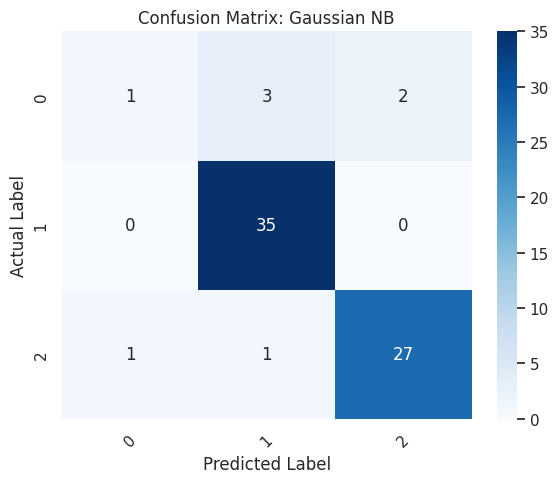

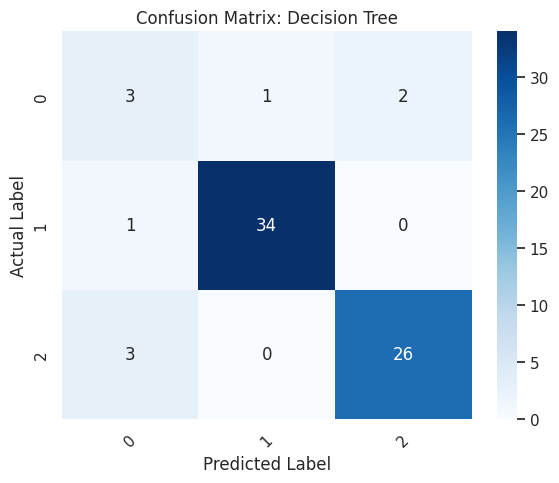

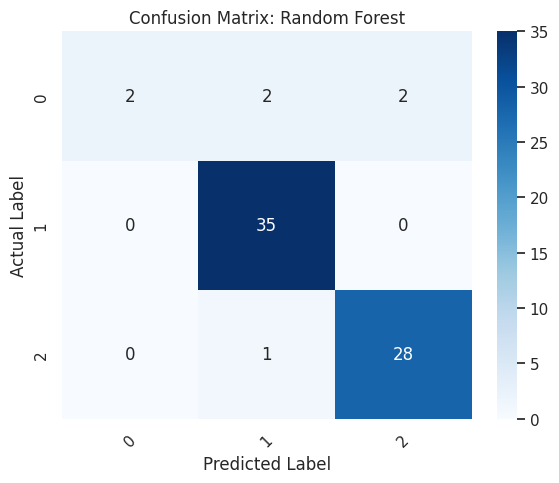

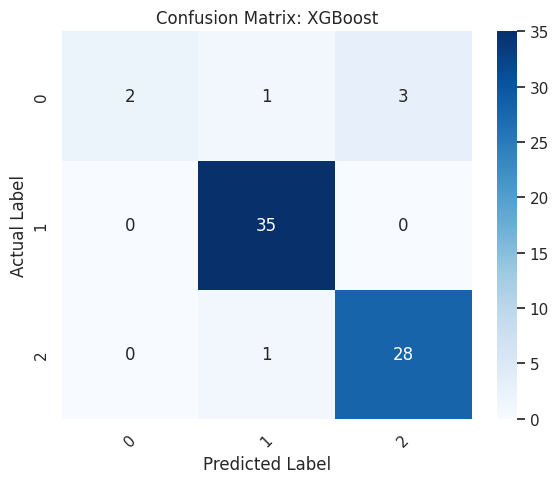

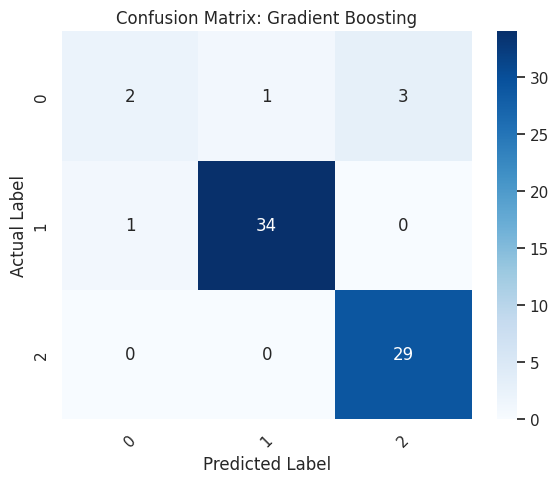

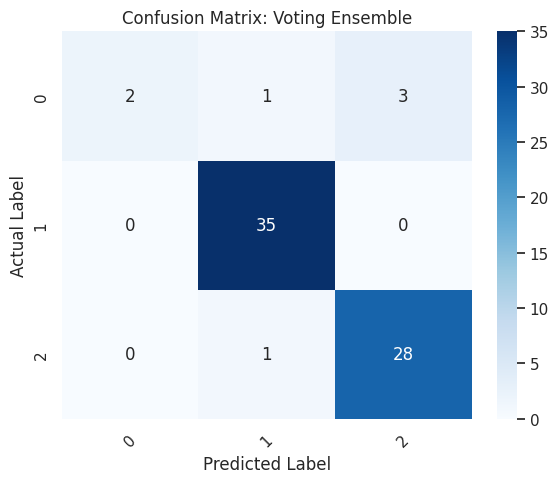

In [ ]:
plot_cm(gnb_model, "Gaussian NB", X_test, y_test)
plot_cm(dt_model, "Decision Tree", X_test, y_test)
plot_cm(rf_model, "Random Forest", X_test, y_test)
plot_cm(xgb_model, "XGBoost", X_test, y_test)
plot_cm(gb_model, "Gradient Boosting", X_test, y_test)
plot_cm(voting_model, "Voting Ensemble", X_test, y_test)

#### Manual tuning

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

gnb_model = GaussianNB(var_smoothing=1e-2)
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    max_depth=4,              # Lebih dangkal dari default (6)
    learning_rate=0.05,       # Belajar lebih lambat (default 0.3)
    subsample=0.8,            # Hanya gunakan 80% sampel di tiap iterasi (Stochastic)
    colsample_bytree=0.8,     # Hanya gunakan 80% kolom/fitur di tiap iterasi
    gamma=0.1,                # Beri penalti jika cabang baru tidak signifikan memisahkan kelas
    random_state=42
)
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,              # Jangan biarkan pohon terlalu dalam
    min_samples_leaf=4,       # Keputusan akhir di daun minimal harus didukung 4 pasien
    random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=200,         # Jumlah pohon diperbanyak agar voting internal lebih stabil
    criterion='gini',
    max_depth=6,              # Batasi kedalaman agar tidak overfit ke kelas mayoritas
    min_samples_leaf=3,
    max_features='sqrt',      # Memaksa pohon melihat kombinasi fitur klinis yang berbeda-beda
    random_state=42
)
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,              # Kedalaman 3 sudah cukup ideal untuk GB
    subsample=0.8,            # Aktifkan Stochastic Gradient Boosting
    min_samples_leaf=3,
    random_state=42
)
voting_model = VotingClassifier(
    estimators=[
        ('gnb', gnb_model),
        ('dt', dt_model),
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('gb', gb_model)
    ],
    voting='soft',
    weights=[1, 1, 2, 2, 2]   # GNB(1), DT(1), RF(2), XGB(2), GB(2)
)

In [ ]:
models = {
    "Gaussian NB": gnb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Gradient Boosting": gb_model,
    "Voting Ensemble": voting_model
}

# Training
print("Memulai proses training...")
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Model {name} telah berhasil dilatih.")

print("\n" + "="*60)
print("EVALUASI DETAIL PER KELAS (CLASSIFICATION REPORT)")
print("="*60)

# List untuk menampung baris hasil
performance_list = []

# Testing & Evaluasi
for name, model in models.items():
    y_pred = model.predict(X_test)

    # Menampilkan performa spesifik per kelas (termasuk kelas Converted)
    print(f"\n--- Performa Model: {name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Menghitung metrik agregat menggunakan 'macro' agar adil terhadap kelas minoritas
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0) * 100

    performance_list.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Macro Precision': round(prec, 2),
        'Macro Recall': round(rec, 2),
        'Macro F1-score': round(f1, 2)
    })

# Menampilkan tabel rangkuman
df_performance = pd.DataFrame(performance_list)
print("\nPerformance evaluation of several ML models")
print(df_performance.to_string(index=False))

# Fungsi Visualisasi Confusion Matrix yang Diperbarui
def plot_cm(model, model_name, X_test, y_test):
    """
    Fungsi untuk memplot confusion matrix.
    Ditambahkan parameter X_test dan y_test agar tidak bergantung pada variabel global.
    """
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Mengambil urutan kelas langsung dari model yang dilatih agar tidak tertukar posisinya
    class_labels = model.classes_

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # Rotasi label x agar tidak saling tumpang tindih jika namanya panjang
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Memulai proses training...
Model Gaussian NB telah berhasil dilatih.
Model Decision Tree telah berhasil dilatih.
Model Random Forest telah berhasil dilatih.
Model XGBoost telah berhasil dilatih.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:22:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Gradient Boosting telah berhasil dilatih.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:22:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Voting Ensemble telah berhasil dilatih.

EVALUASI DETAIL PER KELAS (CLASSIFICATION REPORT)

--- Performa Model: Gaussian NB ---
              precision    recall  f1-score   support

           0       0.50      0.17      0.25         6
           1       0.90      1.00      0.95        35
           2       0.93      0.93      0.93        29

    accuracy                           0.90        70
   macro avg       0.78      0.70      0.71        70
weighted avg       0.88      0.90      0.88        70


--- Performa Model: Decision Tree ---
              precision    recall  f1-score   support

           0       0.25      0.50      0.33         6
           1       0.97      0.91      0.94        35
           2       0.92      0.79      0.85        29

    accuracy                           0.83        70
   macro avg       0.71      0.74      0.71        70
weighted avg       0.89      0.83      0.85        70


--- Performa Model: Random Forest ---
              precision   

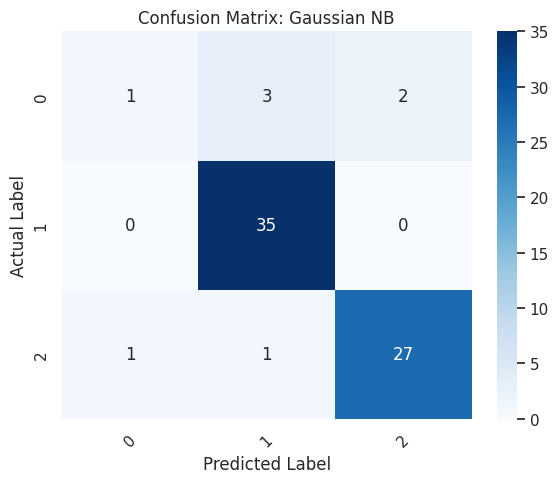

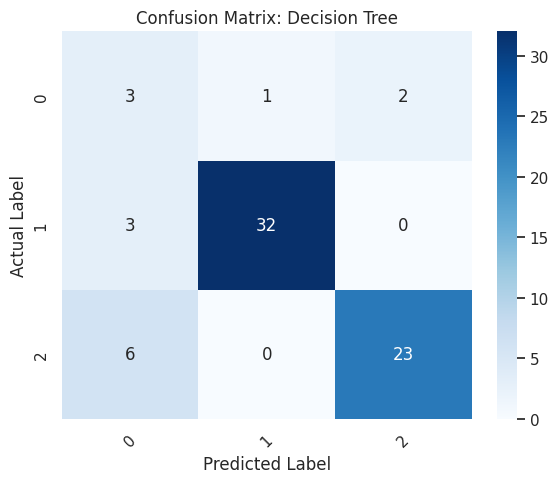

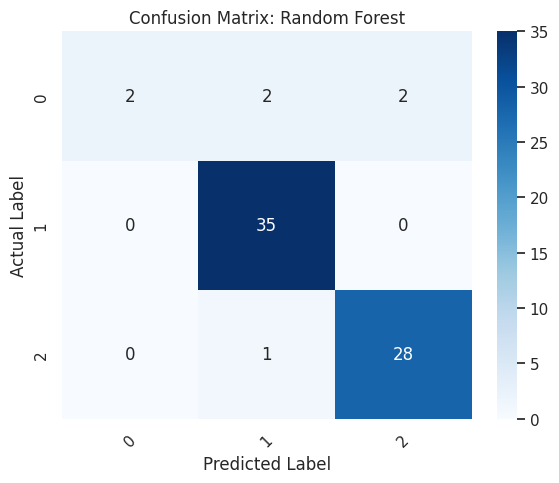

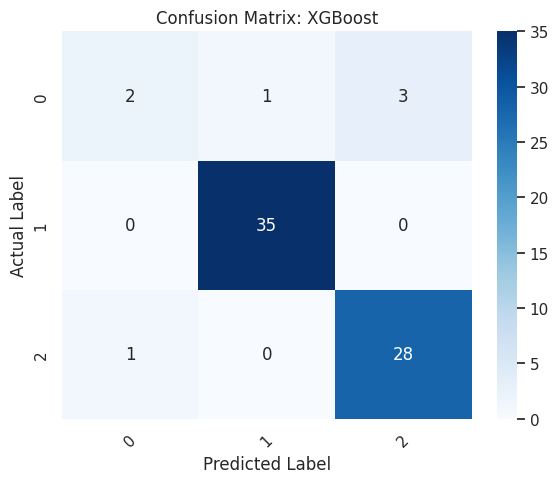

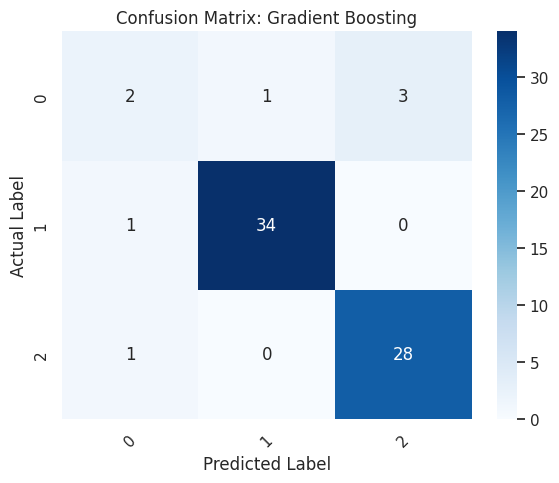

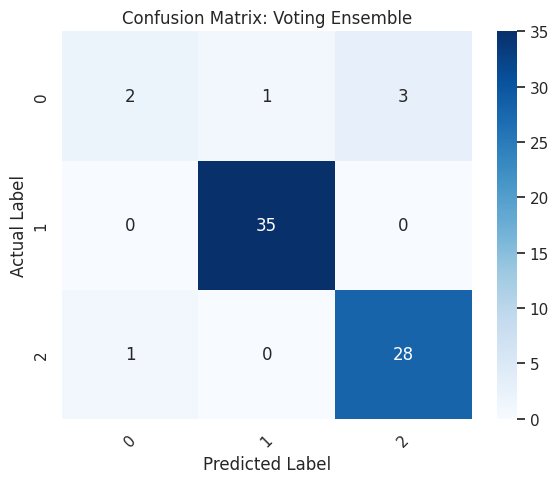

In [ ]:
plot_cm(gnb_model, "Gaussian NB", X_test, y_test)
plot_cm(dt_model, "Decision Tree", X_test, y_test)
plot_cm(rf_model, "Random Forest", X_test, y_test)
plot_cm(xgb_model, "XGBoost", X_test, y_test)
plot_cm(gb_model, "Gradient Boosting", X_test, y_test)
plot_cm(voting_model, "Voting Ensemble", X_test, y_test)

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test_preprocessed)
    print(f"\n=== {name} ===")
    print(classification_report(
        y_test_encoded, y_pred,
        target_names=le.classes_
    ))


=== Gaussian NB ===
              precision    recall  f1-score   support

   Converted       0.50      0.17      0.25         6
    Demented       0.90      1.00      0.95        35
 Nondemented       0.93      0.93      0.93        29

    accuracy                           0.90        70
   macro avg       0.78      0.70      0.71        70
weighted avg       0.88      0.90      0.88        70


=== Decision Tree ===
              precision    recall  f1-score   support

   Converted       0.25      0.50      0.33         6
    Demented       0.97      0.91      0.94        35
 Nondemented       0.92      0.79      0.85        29

    accuracy                           0.83        70
   macro avg       0.71      0.74      0.71        70
weighted avg       0.89      0.83      0.85        70


=== Random Forest ===
              precision    recall  f1-score   support

   Converted       1.00      0.33      0.50         6
    Demented       0.92      1.00      0.96        35
 Nondeme

# Model B

In [ ]:
X_train = X_train_balanced.copy()
X_test = X_test_preprocessed.copy()

y_train = y_train_balanced.copy()
y_test = y_test_encoded.copy()

## Transaction Data Conversion

In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from sklearn.preprocessing import KBinsDiscretizer

In [ ]:
X_train.columns

Index(['MMSE', 'MMSE_drop_so_far', 'nWBV', 'Age', 'EDUC', 'educ_ses',
       'age_nWBV_ratio', 'CDR_Change', 'CDR_Previous', 'CDR_x_MMSE',
       'nWBV_x_CDR_risk', 'age_x_CDR_risk', 'M/F_M', 'CDR', 'CDR_ever_nonzero',
       'at_risk_profile'],
      dtype='object')

In [ ]:
X_train.describe()

,MMSE,MMSE_drop_so_far,nWBV,Age,EDUC,educ_ses,age_nWBV_ratio,CDR_Change,CDR_Previous,CDR_x_MMSE,nWBV_x_CDR_risk,age_x_CDR_risk,M/F_M,CDR,CDR_ever_nonzero,at_risk_profile
count,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000,483.000000
mean,0.020521,0.009882,-0.154199,0.131094,0.056595,-0.146816,-0.159920,0.217697,0.020217,0.151265,0.142210,0.147699,0.434783,0.606625,0.501035,0.325052
std,0.984575,0.993067,0.932963,0.948272,0.919536,0.965282,0.956498,1.117796,1.004241,1.013873,1.008074,1.013539,0.496242,0.686652,0.500517,0.468880
min,-2.091241,-0.567196,-2.309442,-2.280133,-2.957791,-1.705509,-2.722597,-7.742275,-0.542957,-0.852356,-0.866473,-0.866737,0.000000,0.000000,0.000000,0.000000
25%,-0.610875,-0.567196,-0.898238,-0.580711,-0.786506,-1.076976,-0.925384,-0.175348,-0.542957,-0.852356,-0.866473,-0.866737,0.000000,0.000000,0.000000,0.000000
50%,0.375926,-0.567196,-0.275133,0.147236,0.170895,-0.058614,-0.190914,-0.175348,-0.542957,-0.852356,1.051613,1.091356,0.000000,0.000000,1.000000,0.000000
75%,1.053797,0.315147,0.503215,0.857261,0.780668,0.650975,0.481275,-0.175348,-0.542957,1.155478,1.138668,1.158733,1.000000,1.000000,1.000000,1.000000
max,1.053797,1.927907,2.599400,2.687408,2.819828,2.072017,2.636645,3.698211,1.897655,1.573842,1.267732,1.222969,1.000000,3.000000,1.000000,1.000000


In [ ]:
binary_cols = ['M/F_M', 'CDR_ever_nonzero', 'at_risk_profile']
ordinal_cols = ['CDR']
continuous_cols = ['MMSE', 'EDUC', 'Age', 'nWBV']

# drop nearly constant data
continuous_cols = [c for c in continuous_cols if c not in ['MMSE_drop_so_far', 'CDR_Previous']]

In [ ]:
# 1. BUAT DATAFRAME KOSONG DENGAN INDEX X_train
X_binned_df = pd.DataFrame(index=X_train.index)

# 2. MMSE & EDUC pakai pd.cut dengan batas manual
X_binned_df['MMSE'] = pd.cut(X_train['MMSE'], bins=[-1, 18, 23, 30], labels=['Low', 'Mid', 'High'])
X_binned_df['EDUC'] = pd.cut(X_train['EDUC'], bins=[0, 12, 16, 25], labels=['Low', 'Mid', 'High'])

# 3. Age & nWBV pakai KBinsDiscretizer dengan KMeans
from sklearn.preprocessing import KBinsDiscretizer
kbd_kmeans = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='kmeans')
X_binned_train = kbd_kmeans.fit_transform(X_train[['Age', 'nWBV']])
bin_labels = {0: 'Low', 1: 'Mid', 2: 'High'}

X_binned_df['Age']  = [bin_labels[int(v)] for v in X_binned_train[:, 0]]
X_binned_df['nWBV'] = [bin_labels[int(v)] for v in X_binned_train[:, 1]]

### Labeling training data

In [ ]:
# CDR (tanpa reset_index)
X_binned_df['CDR'] = X_train['CDR'].copy().map(lambda v: f"CDR={v}")

# Binary columns (tanpa reset_index)
for col in binary_cols:
    X_binned_df[col] = X_train[col].copy().map(lambda v, c=col: f"{c}=Yes" if v == 1 else f"{c}=No")

In [ ]:
# Keep binary columns as-is with readable labels
for col in binary_cols:
    vals = X_train[col].reset_index(drop=True)
    X_binned_df[col] = vals.map(lambda v, c=col: f"{c}=Yes" if v == 1 else f"{c}=No")

In [ ]:
# Ambil label Group untuk training data
y_train_labels = le.inverse_transform(y_train)  # ['Demented', 'Nondemented', 'Converted', ...]

# Fungsi untuk transaksi TRAINING (dengan label Group)
def row_to_items_train(row, label):
    items = []
    for col in continuous_cols:          # MMSE, EDUC, Age, nWBV
        items.append(f"{col}={row[col]}")
    items.append(row['CDR'])             # CDR=0, CDR=0.5, dst
    for col in binary_cols:             # binary cols
        items.append(row[col])
    items.append(f"Group={label}")      # label target
    return items

def row_to_items(row):
    items = []
    for col in continuous_cols:          # MMSE, EDUC, Age, nWBV
        items.append(f"{col}={row[col]}")
    items.append(row['CDR'])
    for col in binary_cols:
        items.append(row[col])
    return items

X_binned_df_reset = X_binned_df.reset_index(drop=True)

transactions_train = [
    row_to_items_train(X_binned_df_reset.iloc[i], y_train_labels[i])
    for i in range(len(X_binned_df_reset))
]

print(f"Total transactions: {len(transactions_train)}")
print(f"Contoh transaksi pertama: {transactions_train[0]}")

Total transactions: 483
Contoh transaksi pertama: ['MMSE=Low', 'EDUC=nan', 'Age=High', 'nWBV=Low', 'CDR=0.0', 'M/F_M=Yes', 'CDR_ever_nonzero=No', 'at_risk_profile=No', 'Group=Nondemented']


In [ ]:
te = TransactionEncoder()
te_array = te.fit(transactions_train).transform(transactions_train)
X_train_trans = pd.DataFrame(te_array, columns=te.columns_)

In [ ]:
X_train_trans.T

,0,1,2,3,4,5,6,7,8,9,...,473,474,475,476,477,478,479,480,481,482
Age=High,True,True,False,False,False,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
Age=Low,False,False,False,False,False,False,False,True,True,False,...,False,False,True,False,False,True,False,True,True,False
Age=Mid,False,False,True,True,True,False,False,False,False,True,...,True,True,False,False,True,False,True,False,False,False
CDR=0.0,True,True,False,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
CDR=1.0,False,False,True,True,True,False,False,True,False,False,...,True,True,False,True,True,True,True,True,True,False
CDR=2.0,False,False,False,False,False,False,False,False,True,True,...,False,False,True,False,False,False,False,False,False,True
CDR=3.0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
CDR_ever_nonzero=No,True,True,False,False,False,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
CDR_ever_nonzero=Yes,False,False,True,True,True,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
EDUC=Low,False,False,False,False,False,True,True,True,True,True,...,False,True,False,True,False,False,False,True,True,False


In [ ]:
print(f"Transaction matrix shape: {X_train_trans.shape}")
print(f"Total items: {len(te.columns_)}")
print(X_train_trans.head(3))

Transaction matrix shape: (483, 23)
Total items: 23
   Age=High  Age=Low  Age=Mid  CDR=0.0  CDR=1.0  CDR=2.0  CDR=3.0  \
0      True    False    False     True    False    False    False   
1      True    False    False     True    False    False    False   
2     False    False     True    False     True    False    False   

   CDR_ever_nonzero=No  CDR_ever_nonzero=Yes  EDUC=Low  ...  \
0                 True                 False     False  ...   
1                 True                 False     False  ...   
2                False                  True     False  ...   

   Group=Nondemented  M/F_M=No  M/F_M=Yes  MMSE=Low  MMSE=nan  \
0               True     False       True      True     False   
1               True     False       True      True     False   
2              False     False       True     False      True   

   at_risk_profile=No  at_risk_profile=Yes  nWBV=High  nWBV=Low  nWBV=Mid  
0                True                False      False      True     False  
1    

### Labeling Testing Data

In [ ]:
X_test.columns

Index(['MMSE', 'MMSE_drop_so_far', 'nWBV', 'Age', 'EDUC', 'educ_ses',
       'age_nWBV_ratio', 'CDR_Change', 'CDR_Previous', 'CDR_x_MMSE',
       'nWBV_x_CDR_risk', 'age_x_CDR_risk', 'M/F_M', 'CDR', 'CDR_ever_nonzero',
       'at_risk_profile'],
      dtype='object')

In [ ]:
# 1. BUAT DATAFRAME KOSONG DENGAN INDEX X_test
X_binned_test_df = pd.DataFrame(index=X_test.index)

# 2. MMSE & EDUC pakai pd.cut dengan batas manual yang sama dengan training
X_binned_test_df['MMSE'] = pd.cut(X_test['MMSE'], bins=[-1, 18, 23, 30], labels=['Low', 'Mid', 'High'])
X_binned_test_df['EDUC'] = pd.cut(X_test['EDUC'], bins=[0, 12, 16, 25], labels=['Low', 'Mid', 'High'])

# 3. Age & nWBV pakai kbd_kmeans yang sudah di-fit di training
X_binned_test = kbd_kmeans.transform(X_test[['Age', 'nWBV']])
X_binned_test_df['Age']  = [bin_labels[int(v)] for v in X_binned_test[:, 0]]
X_binned_test_df['nWBV'] = [bin_labels[int(v)] for v in X_binned_test[:, 1]]

# 4. CDR (tanpa reset_index)
X_binned_test_df['CDR'] = X_test['CDR'].copy().map(lambda v: f"CDR={v}")

# 5. Binary columns (tanpa reset_index)
for col in binary_cols:
    X_binned_test_df[col] = X_test[col].copy().map(lambda v, c=col: f"{c}=Yes" if v == 1 else f"{c}=No")

# 6. Build transaction list
transactions_test = X_binned_test_df.apply(row_to_items, axis=1).tolist()

# 7. Transform menggunakan te yang sudah di-fit di training
te_array_test = te.transform(transactions_test)
X_test_trans = pd.DataFrame(te_array_test, columns=te.columns_, index=X_test.index)

print(f"X_test transaction matrix shape: {X_test_trans.shape}")
print(X_test_trans.head(2))

X_test transaction matrix shape: (70, 23)
   Age=High  Age=Low  Age=Mid  CDR=0.0  CDR=1.0  CDR=2.0  CDR=3.0  \
7     False    False     True     True    False    False    False   
8     False    False     True    False     True    False    False   

   CDR_ever_nonzero=No  CDR_ever_nonzero=Yes  EDUC=Low  ...  \
7                 True                 False     False  ...   
8                False                  True     False  ...   

   Group=Nondemented  M/F_M=No  M/F_M=Yes  MMSE=Low  MMSE=nan  \
7              False     False       True      True     False   
8              False     False       True      True     False   

   at_risk_profile=No  at_risk_profile=Yes  nWBV=High  nWBV=Low  nWBV=Mid  
7                True                False      False     False      True  
8                True                False      False     False      True  

[2 rows x 23 columns]


In [ ]:
print(f"X_test transaction matrix shape: {X_test_trans.shape}")
print(X_test_trans.head(2))

X_test transaction matrix shape: (70, 23)
   Age=High  Age=Low  Age=Mid  CDR=0.0  CDR=1.0  CDR=2.0  CDR=3.0  \
7     False    False     True     True    False    False    False   
8     False    False     True    False     True    False    False   

   CDR_ever_nonzero=No  CDR_ever_nonzero=Yes  EDUC=Low  ...  \
7                 True                 False     False  ...   
8                False                  True     False  ...   

   Group=Nondemented  M/F_M=No  M/F_M=Yes  MMSE=Low  MMSE=nan  \
7              False     False       True      True     False   
8              False     False       True      True     False   

   at_risk_profile=No  at_risk_profile=Yes  nWBV=High  nWBV=Low  nWBV=Mid  
7                True                False      False     False      True  
8                True                False      False     False      True  

[2 rows x 23 columns]


## Frequent itemset mining

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

frequent_itemsets = fpgrowth(
    X_train_trans,
    min_support=0.2,       # adjust: lower = more itemsets, higher = fewer
    use_colnames=True
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Total frequent itemsets found: 192
      support                                 itemsets  length
0    0.828157                               (MMSE=Low)       1
1    0.674948                     (at_risk_profile=No)       1
20   0.602484           (MMSE=Low, at_risk_profile=No)       2
15   0.565217                               (M/F_M=No)       1
16   0.544513                               (EDUC=Low)       1
175  0.507246                     (MMSE=Low, M/F_M=No)       2
2    0.503106                                (CDR=0.0)       1
21   0.503106                      (MMSE=Low, CDR=0.0)       2
22   0.501035            (CDR=0.0, at_risk_profile=No)       2
25   0.501035  (MMSE=Low, CDR=0.0, at_risk_profile=No)       3


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

rules = rules.sort_values(['lift', 'confidence'], ascending=False)
print(f"Total rules: {len(rules)}")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Total rules: 751
                                           antecedents  \
713                     (CDR=1.0, at_risk_profile=Yes)   
714                   (MMSE=Low, CDR_ever_nonzero=Yes)   
686                   (EDUC=nan, CDR_ever_nonzero=Yes)   
688                                   (Group=Demented)   
718                   (CDR_ever_nonzero=Yes, nWBV=Low)   
721                              (at_risk_profile=Yes)   
668                   (MMSE=Low, CDR_ever_nonzero=Yes)   
669                                          (CDR=1.0)   
706                    (MMSE=Low, at_risk_profile=Yes)   
711  (MMSE=Low, CDR_ever_nonzero=Yes, at_risk_profi...   

                          consequents   support  confidence      lift  
713  (MMSE=Low, CDR_ever_nonzero=Yes)  0.207039    0.813008  2.469704  
714    (CDR=1.0, at_risk_profile=Yes)  0.207039    0.628931  2.469704  
686                  (Group=Demented)  0.200828    0.822034  2.466102  
688  (EDUC=nan, CDR_ever_nonzero=Yes)  0.200828    0.602

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Filter: high confidence + lift > 1.5 + max antecedent length to avoid trivial rules
rules_filtered = rules[
    (rules['confidence'] >= 0.75) &
    (rules['lift'] >= 1.5) &
    (rules['antecedents'].apply(len) <= 3) &
    (rules['consequents'].apply(len) == 1)   # single consequent = more interpretable
].sort_values(['lift', 'confidence'], ascending=False)

print(f"Filtered rules: {len(rules_filtered)}")
print(rules_filtered[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Filtered rules: 96
                                           antecedents            consequents  \
686                   (EDUC=nan, CDR_ever_nonzero=Yes)       (Group=Demented)   
718                   (CDR_ever_nonzero=Yes, nWBV=Low)  (at_risk_profile=Yes)   
668                   (MMSE=Low, CDR_ever_nonzero=Yes)              (CDR=1.0)   
706                    (MMSE=Low, at_risk_profile=Yes)              (CDR=1.0)   
711  (MMSE=Low, CDR_ever_nonzero=Yes, at_risk_profi...              (CDR=1.0)   
672                   (EDUC=Low, CDR_ever_nonzero=Yes)              (CDR=1.0)   
665                    (CDR_ever_nonzero=Yes, Age=Mid)              (CDR=1.0)   
98                                 (CDR=0.0, M/F_M=No)  (CDR_ever_nonzero=No)   
116                      (MMSE=Low, CDR=0.0, M/F_M=No)  (CDR_ever_nonzero=No)   
129            (at_risk_profile=No, CDR=0.0, M/F_M=No)  (CDR_ever_nonzero=No)   

      support  confidence      lift  
686  0.200828    0.822034  2.466102  
718  0.213251

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Target consequent = label Group (target variabel klasifikasi)
target_consequents = {
    'Group=Demented',
    'Group=Nondemented',
    'Group=Converted'
}

def is_target_consequent(consequents):
    return any(item in target_consequents for item in consequents)

rules_clinical = rules[
    (rules['confidence'] >= 0.75) &
    (rules['lift'] >= 1.2) &
    (rules['antecedents'].apply(len) <= 3) &
    (rules['consequents'].apply(len) == 1) &
    (rules['consequents'].apply(is_target_consequent))
].sort_values(['lift', 'confidence'], ascending=False)

print(f"Clinically relevant rules: {len(rules_clinical)}")
print(rules_clinical[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Clinically relevant rules: 1
                          antecedents       consequents   support  confidence  \
686  (EDUC=nan, CDR_ever_nonzero=Yes)  (Group=Demented)  0.200828    0.822034   

         lift  
686  2.466102  


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ============================================================
# OPTION 1: Binary features dari Frequent Itemsets
# ============================================================
def encode_itemsets(X_trans, itemsets_df, min_length=2, top_n=30):
    filtered = itemsets_df[itemsets_df['length'] >= min_length]
    filtered = filtered.sort_values('support', ascending=False).head(top_n)

    features = {}
    for i, row in filtered.iterrows():
        items = list(row['itemsets'])
        # Pastikan semua item ada di kolom X_trans
        valid_items = [it for it in items if it in X_trans.columns]
        if len(valid_items) == len(items):
            col_name = "FP_" + "__".join(sorted(valid_items))
            col_name = col_name[:80]  # batasi panjang nama kolom
            features[col_name] = X_trans[valid_items].all(axis=1).astype(int)

    return pd.DataFrame(features)

X_train_itemsets = encode_itemsets(X_train_trans, frequent_itemsets, min_length=2, top_n=30)
X_test_itemsets  = encode_itemsets(X_test_trans,  frequent_itemsets, min_length=2, top_n=30)

X_train_itemsets = X_train_itemsets.reset_index(drop=True)
X_test_itemsets  = X_test_itemsets.reset_index(drop=True)

print(f"Option 1 - Itemset features — train: {X_train_itemsets.shape}, test: {X_test_itemsets.shape}")
print(X_train_itemsets.head(3))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Option 1 - Itemset features — train: (483, 30), test: (70, 30)
   FP_MMSE=Low__at_risk_profile=No  FP_M/F_M=No__MMSE=Low  \
0                                1                      0   
1                                1                      0   
2                                0                      0   

   FP_CDR=0.0__MMSE=Low  FP_CDR=0.0__at_risk_profile=No  \
0                     1                               1   
1                     1                               1   
2                     0                               0   

   FP_CDR=0.0__MMSE=Low__at_risk_profile=No  \
0                                         1   
1                                         1   
2                                         0   

   FP_CDR=0.0__CDR_ever_nonzero=No__at_risk_profile=No  \
0                                                  1     
1                                                  1     
2                                                  0     

   FP_CDR_ever_nonzero=No__MMSE=L

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
def encode_rules(X_trans, rules_df, top_n=50):
    top_rules = rules_df.head(top_n)
    features = {}

    for i, row in top_rules.iterrows():
        antecedents = list(row['antecedents'])
        consequents = list(row['consequents'])
        rule_name = f"rule_{i}_{'_'.join(consequents)}"

        # 1 if all antecedent items are present in the transaction
        features[rule_name] = X_trans[antecedents].all(axis=1).astype(int)

    return pd.DataFrame(features)

# Apply to train and test
X_train_rules = encode_rules(X_train_trans, rules_clinical, top_n=50)
X_test_rules  = encode_rules(X_test_trans,  rules_clinical, top_n=50)

# Concatenate with original transaction features
# Reset index untuk menghindari mismatch saat concat
X_train_orig = X_train_balanced.reset_index(drop=True)
X_test_orig  = X_test_preprocessed.reset_index(drop=True)

X_train_rules = X_train_rules.reset_index(drop=True)
X_test_rules  = X_test_rules.reset_index(drop=True)

# Fitur original + fitur baru dari rules (AUGMENT, bukan replace)
# Reset semua index sebelum concat
X_train_orig     = X_train_balanced.reset_index(drop=True)
X_test_orig      = X_test_preprocessed.reset_index(drop=True)
X_train_itemsets = X_train_itemsets.reset_index(drop=True)
X_test_itemsets  = X_test_itemsets.reset_index(drop=True)
X_train_rules    = X_train_rules.reset_index(drop=True)
X_test_rules     = X_test_rules.reset_index(drop=True)

# Gabungkan: fitur original + Option 1 (itemsets) + Option 2 (rules)
X_train_final = pd.concat([X_train_orig, X_train_itemsets, X_train_rules], axis=1)
X_test_final  = pd.concat([X_test_orig,  X_test_itemsets,  X_test_rules],  axis=1)

# Hapus kolom duplikat jika ada
X_train_final = X_train_final.loc[:, ~X_train_final.columns.duplicated()]
X_test_final  = X_test_final.loc[:,  ~X_test_final.columns.duplicated()]

print(f"Fitur original      : {X_train_orig.shape[1]} kolom")
print(f"Fitur Option 1 (FP) : {X_train_itemsets.shape[1]} kolom")
print(f"Fitur Option 2 (AR) : {X_train_rules.shape[1]} kolom")
print(f"Total final — train : {X_train_final.shape}, test: {X_test_final.shape}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Fitur original      : 16 kolom
Fitur Option 1 (FP) : 30 kolom
Fitur Option 2 (AR) : 1 kolom
Total final — train : (483, 47), test: (70, 47)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Cek kolom yang hilang atau lebih
missing_in_test = set(X_train_final.columns) - set(X_test_final.columns)
extra_in_test   = set(X_test_final.columns)  - set(X_train_final.columns)

if missing_in_test:
    print(f"⚠️  Kolom ada di train tapi tidak di test: {missing_in_test}")
    for col in missing_in_test:
        X_test_final[col] = 0  # pola tidak ditemukan di test → isi 0

if extra_in_test:
    print(f"⚠️  Kolom ada di test tapi tidak di train: {extra_in_test}")
    X_test_final = X_test_final.drop(columns=list(extra_in_test))

# Samakan urutan kolom test dengan train
X_test_final = X_test_final[X_train_final.columns]

assert list(X_train_final.columns) == list(X_test_final.columns), "Column mismatch!"
assert X_train_final.shape[1] == X_test_final.shape[1], "Feature count mismatch!"
print(f"✅ Train: {X_train_final.shape}, Test: {X_test_final.shape} — kolom sudah match")

✅ Train: (483, 47), Test: (70, 47) — kolom sudah match


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Training feature engineered model

In [ ]:
!pip install xgboost

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
gnb_model = GaussianNB()
xgb_model = XGBClassifier()
dt_model = DecisionTreeClassifier()
rf_model = RandomForestClassifier()
gb_model = GradientBoostingClassifier()
voting_model = VotingClassifier(
    estimators=[('gnb', gnb_model), ('rf', rf_model), ('xgb', xgb_model), ('dt', dt_model), ('gb', gb_model)],
    voting='soft'
)

models = {
    "Gaussian NB": gnb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Gradient Boosting": gb_model,
    "Voting Ensemble": voting_model
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Training
print("Memulai proses training...")
for name, model in models.items():
    model.fit(X_train_final, y_train)
    print(f"Model {name} telah berhasil dilatih.")

print("\n" + "="*60)
print("EVALUASI DETAIL PER KELAS (CLASSIFICATION REPORT)")
print("="*60)

# List untuk menampung baris hasil
performance_list = []

# Testing & Evaluasi
for name, model in models.items():
    y_pred = model.predict(X_test_final)

    # Menampilkan performa spesifik per kelas (termasuk kelas Converted)
    print(f"\n--- Performa Model: {name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Menghitung metrik agregat menggunakan 'macro' agar adil terhadap kelas minoritas
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0) * 100

    performance_list.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Macro Precision': round(prec, 2),
        'Macro Recall': round(rec, 2),
        'Macro F1-score': round(f1, 2)
    })

# Menampilkan tabel rangkuman
df_performance = pd.DataFrame(performance_list)
print("\nPerformance evaluation of several ML models")
print(df_performance.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Memulai proses training...
Model Gaussian NB telah berhasil dilatih.
Model Decision Tree telah berhasil dilatih.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Model Random Forest telah berhasil dilatih.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         6
           1       0.92      1.00      0.96        35
           2       0.93      0.97      0.95        29

    accuracy                           0.93        70
   macro avg       0.95      0.77      0.80        70
weighted avg       0.93      0.93      0.92        70


--- Performa Model: XGBoost ---
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         6
           1       0.95      1.00      0.97        35
           2       0.90      0.90      0.90        29

    accuracy                           0.90        70
   macro avg       0.78      0.74      0.76        70
weighted avg       0.89      0.90      0.89        70


--- Performa Model: Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.94      0.97      0.96        35

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Performa Model: Voting Ensemble ---
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.95      1.00      0.97        35
           2       0.93      0.97      0.95        29

    accuracy                           0.94        70
   macro avg       0.96      0.82      0.86        70
weighted avg       0.95      0.94      0.94        70


Performance evaluation of several ML models
            Model  Accuracy (%)  Macro Precision  Macro Recall  Macro F1-score
      Gaussian NB         90.00            77.62         69.92           70.90
    Decision Tree         87.14            74.26         76.63           74.81
    Random Forest         92.86            95.15         76.63           80.27
          XGBoost         90.00            78.08         74.33           75.63
Gradient Boosting         92.86            84.89         76.83           78.96
  Voting Ensemble         94.29            95.98         82

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

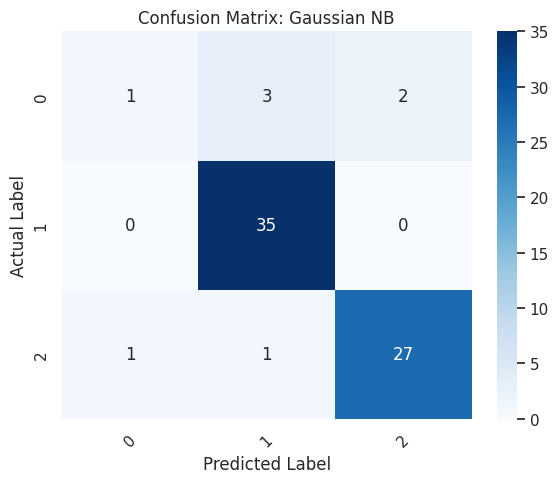

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

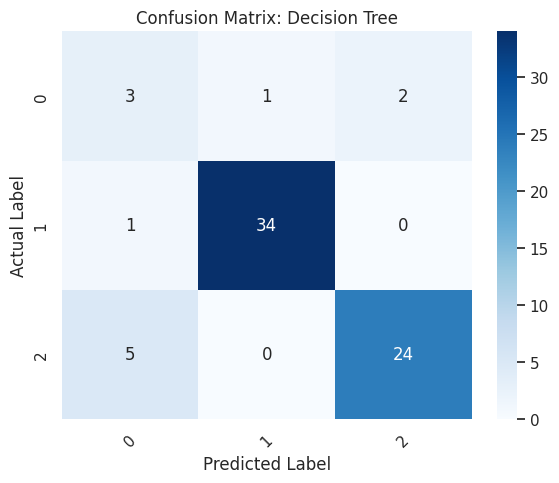

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

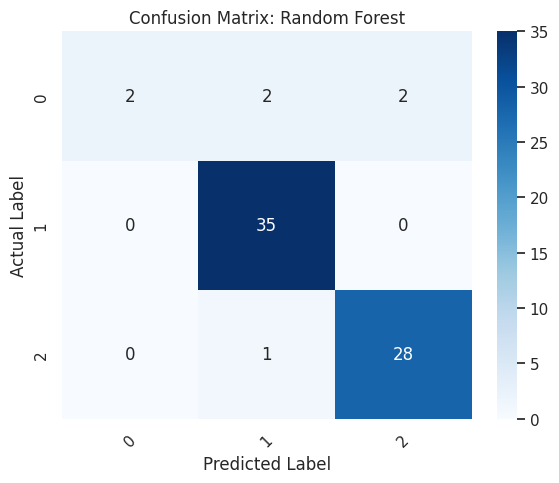

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

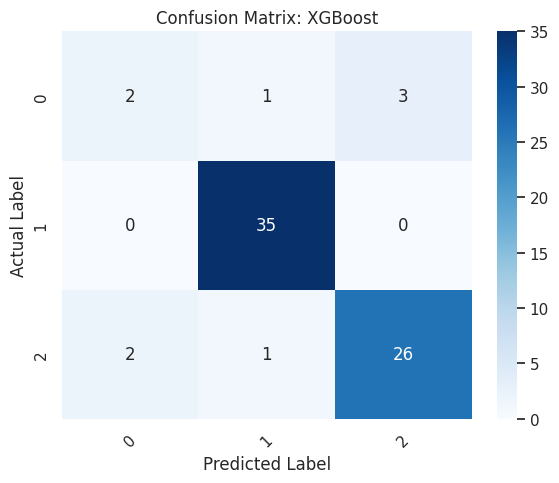

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

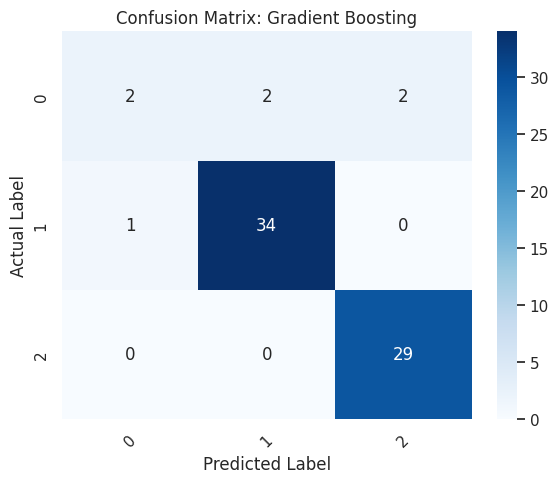

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

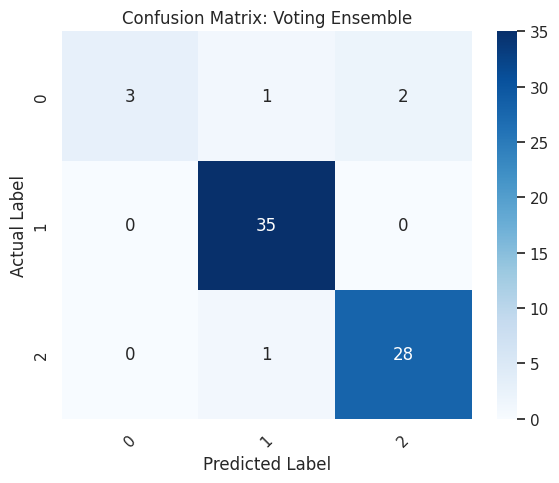

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Fungsi Visualisasi Confusion Matrix yang Diperbarui
def plot_cm(model, model_name, X_test, y_test):
    """
    Fungsi untuk memplot confusion matrix.
    Ditambahkan parameter X_test dan y_test agar tidak bergantung pada variabel global.
    """
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Mengambil urutan kelas langsung dari model yang dilatih agar tidak tertukar posisinya
    class_labels = model.classes_

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # Rotasi label x agar tidak saling tumpang tindih jika namanya panjang
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_cm(gnb_model, "Gaussian NB", X_test_final, y_test)
plot_cm(dt_model, "Decision Tree", X_test_final, y_test)
plot_cm(rf_model, "Random Forest", X_test_final, y_test)
plot_cm(xgb_model, "XGBoost", X_test_final, y_test)
plot_cm(gb_model, "Gradient Boosting", X_test_final, y_test)
plot_cm(voting_model, "Voting Ensemble", X_test_final, y_test)

## Manual tuning

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

gnb_model = GaussianNB(var_smoothing=1e-2)
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    max_depth=4,              # Lebih dangkal dari default (6)
    learning_rate=0.05,       # Belajar lebih lambat (default 0.3)
    subsample=0.8,            # Hanya gunakan 80% sampel di tiap iterasi (Stochastic)
    colsample_bytree=0.8,     # Hanya gunakan 80% kolom/fitur di tiap iterasi
    gamma=0.1,                # Beri penalti jika cabang baru tidak signifikan memisahkan kelas
    random_state=42
)
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,              # Jangan biarkan pohon terlalu dalam
    min_samples_leaf=4,       # Keputusan akhir di daun minimal harus didukung 4 pasien
    random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=200,         # Jumlah pohon diperbanyak agar voting internal lebih stabil
    criterion='gini',
    max_depth=6,              # Batasi kedalaman agar tidak overfit ke kelas mayoritas
    min_samples_leaf=3,
    max_features='sqrt',      # Memaksa pohon melihat kombinasi fitur klinis yang berbeda-beda
    random_state=42
)
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,              # Kedalaman 3 sudah cukup ideal untuk GB
    subsample=0.8,            # Aktifkan Stochastic Gradient Boosting
    min_samples_leaf=3,
    random_state=42
)
voting_model = VotingClassifier(
    estimators=[
        ('gnb', gnb_model),
        ('dt', dt_model),
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('gb', gb_model)
    ],
    voting='soft',
    weights=[1, 1, 2, 2, 2]   # GNB(1), DT(1), RF(2), XGB(2), GB(2)
)

models = {
    "Gaussian NB": gnb_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Gradient Boosting": gb_model,
    "Voting Ensemble": voting_model
}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Training
print("Memulai proses training...")
for name, model in models.items():
    model.fit(X_train_final, y_train)
    print(f"Model {name} telah berhasil dilatih.")

print("\n" + "="*60)
print("EVALUASI DETAIL PER KELAS (CLASSIFICATION REPORT)")
print("="*60)

# List untuk menampung baris hasil
performance_list = []

# Testing & Evaluasi
for name, model in models.items():
    y_pred = model.predict(X_test_final)

    # Menampilkan performa spesifik per kelas (termasuk kelas Converted)
    print(f"\n--- Performa Model: {name} ---")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Menghitung metrik agregat menggunakan 'macro' agar adil terhadap kelas minoritas
    acc = accuracy_score(y_test, y_pred) * 100
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0) * 100
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0) * 100

    performance_list.append({
        'Model': name,
        'Accuracy (%)': round(acc, 2),
        'Macro Precision': round(prec, 2),
        'Macro Recall': round(rec, 2),
        'Macro F1-score': round(f1, 2)
    })

# Menampilkan tabel rangkuman
df_performance = pd.DataFrame(performance_list)
print("\nPerformance evaluation of several ML models")
print(df_performance.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Memulai proses training...
Model Gaussian NB telah berhasil dilatih.
Model Decision Tree telah berhasil dilatih.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Model Random Forest telah berhasil dilatih.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Performa Model: Gradient Boosting ---
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         6
           1       0.94      0.97      0.96        35
           2       0.93      0.97      0.95        29

    accuracy                           0.91        70
   macro avg       0.79      0.76      0.77        70
weighted avg       0.90      0.91      0.91        70


--- Performa Model: Voting Ensemble ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

              precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.95      1.00      0.97        35
           2       0.93      0.97      0.95        29

    accuracy                           0.93        70
   macro avg       0.85      0.77      0.79        70
weighted avg       0.92      0.93      0.92        70


Performance evaluation of several ML models
            Model  Accuracy (%)  Macro Precision  Macro Recall  Macro F1-score
      Gaussian NB         90.00            77.62         69.92           70.90
    Decision Tree         85.71            73.12         75.68           73.47
    Random Forest         91.43            94.28         75.48           79.23
          XGBoost         91.43            79.16         75.68           76.83
Gradient Boosting         91.43            79.26         75.68           76.90
  Voting Ensemble         92.86            84.86         76.63           78.86


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

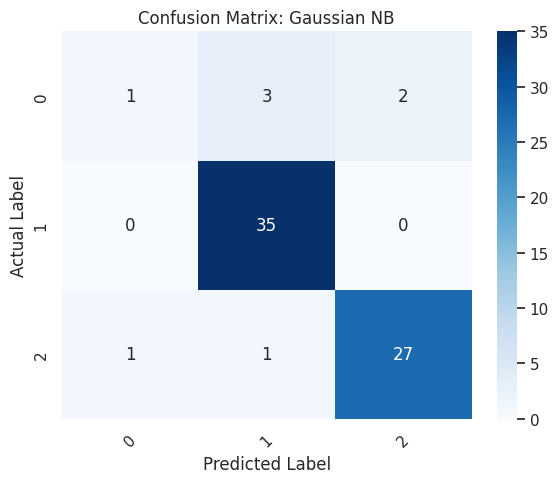

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

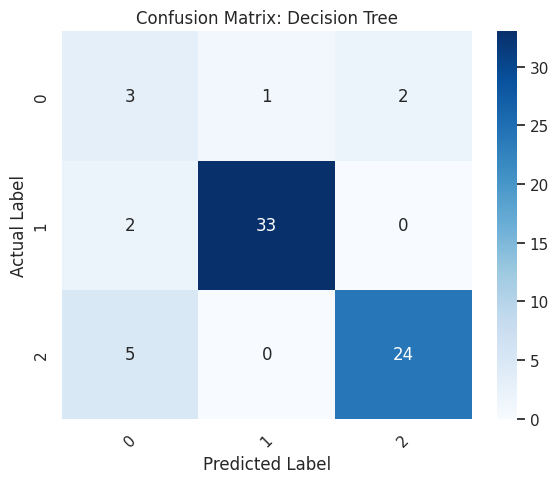

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

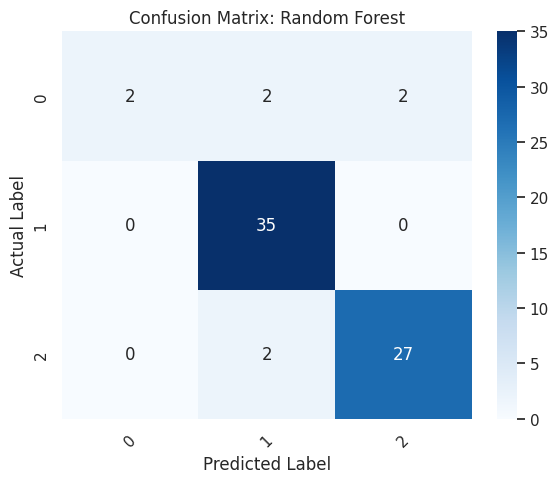

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

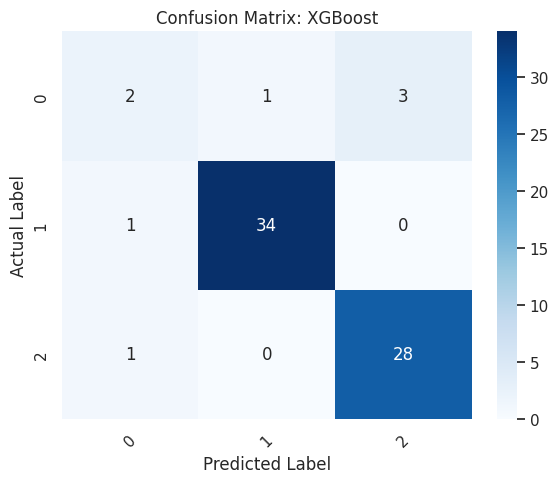

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

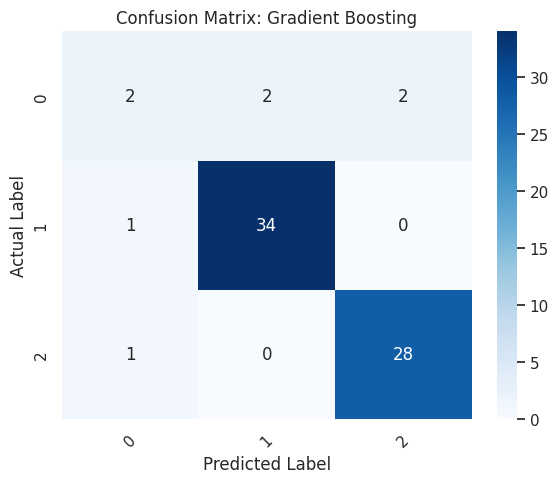

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

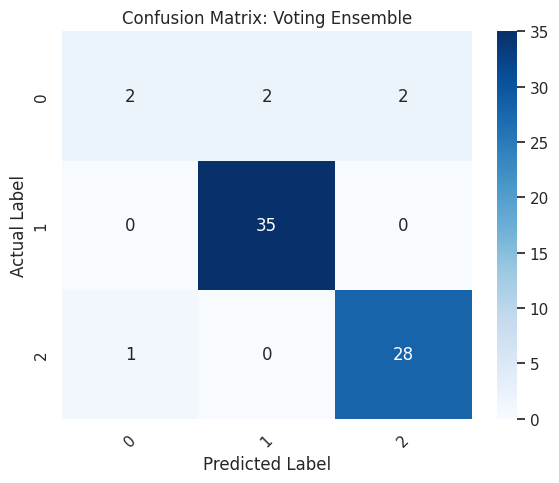

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Fungsi Visualisasi Confusion Matrix yang Diperbarui
def plot_cm(model, model_name, X_test, y_test):
    """
    Fungsi untuk memplot confusion matrix.
    Ditambahkan parameter X_test dan y_test agar tidak bergantung pada variabel global.
    """
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Mengambil urutan kelas langsung dari model yang dilatih agar tidak tertukar posisinya
    class_labels = model.classes_

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # Rotasi label x agar tidak saling tumpang tindih jika namanya panjang
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_cm(gnb_model, "Gaussian NB", X_test_final, y_test)
plot_cm(dt_model, "Decision Tree", X_test_final, y_test)
plot_cm(rf_model, "Random Forest", X_test_final, y_test)
plot_cm(xgb_model, "XGBoost", X_test_final, y_test)
plot_cm(gb_model, "Gradient Boosting", X_test_final, y_test)
plot_cm(voting_model, "Voting Ensemble", X_test_final, y_test)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag